# **Case Study — Análise Exploratória e Predição do Rendimento Metálico**


---

## **Contexto**

---

Em uma aciaria , **cada corrida gera dezenas de variáveis**: o mix de sucata carregado,
os consumos do forno (energia, oxigênio, gás natural, fundentes), a composição química da
escória e os tempos de operação. Entender **como essas variáveis se relacionam entre si e com o
rendimento metálico** é a base para qualquer projeto de melhoria.

O **rendimento metálico** mede a eficiência de conversão da carga sólida em aço líquido:

$$\boxed{\text{Rendimento Metálico (\%)} = \frac{\text{Aço líquido vazado (t)}}{\text{Carga metálica enfornada (t)}} \times 100}$$


---

## **Objetivo deste estudo**

---

O foco aqui é a **Análise Exploratória de Dados (EDA)** —

1. **Auditar e limpar** os dados (faltantes, inconsistências de cadastro);
2. **Compreender cada variável** isoladamente (análise univariada);
3. **Investigar relações** entre variáveis (análise bivariada e de correlação);
4. **Interpretar a multicolinearidade** sob a ótica metalúrgica;
5. E, ao final, construir um **modelo de regressão linear** de forma enxuta, como
   consequência natural da boa EDA — e não como um fim em si mesmo.

> 🎓 **Filosofia do estudo:** *"80% do trabalho de um cientista de dados é entender e preparar
> os dados; 20% é modelar."* — para um engenheiro de processos, a EDA é onde o conhecimento de
> processo encontra a estatística.

---

## **Dataset**

---

Uma única planilha (`aciaria_rendimento.csv`) com **1.300 corridas**. O notebook fará a
separação automática em treino/teste. As variáveis estão organizadas em **5 blocos**:


**Bloco 1 — Variáveis categóricas**

| Variável | Descrição |
|---|---|
| `Tipo_Aco` | Grade produzida (SAE 1020 / SAE 1045 / CA-50) |
| `Turno` | Turno de produção — **com inconsistências de cadastro!** |
| `Estado_Forno` | Condição operacional (Normal / Pós-parada / Pré-parada) |

**Bloco 2 — Mix de sucata (% de cada tipo na carga — soma ≈ 100%)**

| Variável | Tipo de sucata |
|---|---|
| `Sucata_SGUS_pct` | Gusa sólido |
| `Sucata_SSHR_pct` | Shredder (fragmentada) |
| `Sucata_SPES_pct` | Pesada |
| `Sucata_SREC_pct` | Retorno/recuperada |
| `Sucata_STES_pct` | Tesoura/tosa |
| `Sucata_SMIU_pct` | Miúda |
| `Sucata_SMIST_pct` | Mista |

**Bloco 3 — Composição da escória** *(análise nem sempre realizada → faltantes)*

| Variável | Descrição |
|---|---|
| `FeO_Escoria_pct` | % de FeO — perda direta de ferro |
| `CaO_Escoria_pct` | % de CaO |
| `SiO2_Escoria_pct` | % de SiO₂ |
| `MgO_Escoria_pct` | % de MgO (saturação do refratário) |
| `MnO_Escoria_pct` | % de MnO |
| `Al2O3_Escoria_pct` | % de Al₂O₃ |
| `Basicidade_B2` | CaO / SiO₂ |

**Bloco 4 — Consumos e operação do forno**

| Variável | Descrição |
|---|---|
| `Energia_kWh_t` | Energia elétrica específica |
| `O2_Especifico_Nm3_t` | Oxigênio soprado específico |
| `GasNatural_Nm3_t` | Gás natural (queimadores) |
| `Cal_kg_t` / `Dolomita_kg_t` | Fundentes |
| `C_Injetado_kg_t` | Carbono injetado |
| `PowerOn_min` / `PowerOff_min` | Tempo com/sem arco energizado |
| `TapToTap_min` | Tempo total da corrida |
| `Pot_Media_MW` | Potência média |
| `Temp_Vazamento_C` | Temperatura de vazamento |

**Bloco 5 — Variáveis elétricas medidas**

| Variável | Descrição |
|---|---|
| `Fator_Potencia` | Fator de potência medido |
| `THD_pct` | Distorção harmônica total medida |

**Resposta:** `Rendimento_pct` (%)


---
## **Importação das bibliotecas**

In [28]:
# Manipulação de dados
import numpy as np
import pandas as pd

# Visualização
import seaborn as sns
import matplotlib.pyplot as plt

# Modelagem e diagnóstico
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.compat import lzip

# Avaliação / split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})
sns.set_palette(["#0E2A47","#F08C00","#C0392B","#1E7F4F","#8E44AD"])
print("Bibliotecas carregadas.")

Bibliotecas carregadas.


### **Carregamento dos dados**

In [29]:
# ==================================================================
# UPLOAD DE PLANILHA EXCEL + LEITURA DAS COLUNAS COMO VARIAVEIS
# ==================================================================
import os, shutil, tempfile, io

caminho_arquivo = None

# 1) Tenta o ambiente Google Colab (botao de upload)
try:
    from google.colab import files
    print("Ambiente Colab detectado. Faca o upload da planilha (.xlsx/.xls/.csv)...")
    enviados = files.upload()
    caminho_arquivo = list(enviados.keys())[0]
except ImportError:
    # 2) Ambiente local (Windows): abre o dialogo nativo de selecao de arquivo
    try:
        import tkinter as tk
        from tkinter import filedialog
        root = tk.Tk(); root.withdraw(); root.attributes('-topmost', True)
        caminho_arquivo = filedialog.askopenfilename(
            title="Selecione a planilha (Excel ou CSV)",
            filetypes=[("Planilhas", "*.xlsx *.xls *.csv"), ("Todos os arquivos", "*.*")])
        root.destroy()
    except Exception as e:
        print(f"Nao foi possivel abrir o dialogo grafico ({e}).")
        caminho_arquivo = input("Digite o caminho completo da planilha: ").strip('" ')

if not caminho_arquivo:
    raise FileNotFoundError("Nenhum arquivo selecionado. Execute a celula novamente e escolha a planilha.")

print(f"Arquivo selecionado: {caminho_arquivo}")

# ------------------------------------------------------------------
# Leitura robusta: carrega os bytes do arquivo, contornando bloqueio
# do Excel/OneDrive (PermissionError - Errno 13)
# ------------------------------------------------------------------
def _carregar_bytes(caminho):
    """Le os bytes do arquivo. Em caso de PermissionError (arquivo aberto no
    Excel ou placeholder online-only do OneDrive), copia para a pasta temporaria
    e tenta novamente."""
    try:
        with open(caminho, 'rb') as f:
            return f.read()
    except PermissionError:
        print("[!] Acesso negado ao arquivo. Tentando copiar para pasta temporaria...")
        try:
            destino = os.path.join(tempfile.gettempdir(), os.path.basename(caminho))
            shutil.copy2(caminho, destino)
            with open(destino, 'rb') as f:
                return f.read()
        except Exception as e:
            raise PermissionError(
                "Nao foi possivel ler a planilha (Errno 13 - Permissao negada).\n"
                "Causas mais comuns e solucoes:\n"
                "  1) O arquivo esta ABERTO no Excel  -> feche o Excel e rode a celula de novo.\n"
                "  2) Arquivo OneDrive 'apenas online'  -> clique direito > 'Manter sempre neste\n"
                "     dispositivo' para baixa-lo localmente, depois rode novamente.\n"
                "  3) Salve uma copia em uma pasta local (ex.: Downloads) e selecione-a.\n"
                f"\nDetalhe tecnico: {e}"
            )

_dados = _carregar_bytes(caminho_arquivo)

# ------------------------------------------------------------------
# Leitura (Excel ou CSV). Para Excel com varias abas, usa a com mais linhas
# ------------------------------------------------------------------
if str(caminho_arquivo).lower().endswith('.csv'):
    df = pd.read_csv(io.BytesIO(_dados))
else:
    xls = pd.ExcelFile(io.BytesIO(_dados))
    if len(xls.sheet_names) > 1:
        contagens = {s: len(pd.read_excel(xls, sheet_name=s, usecols=[0])) for s in xls.sheet_names}
        aba = max(contagens, key=contagens.get)
        print(f"Abas encontradas: {xls.sheet_names} -> usando '{aba}' (maior numero de linhas)")
    else:
        aba = xls.sheet_names[0]
    df = pd.read_excel(xls, sheet_name=aba, header=0)

# Remove colunas sem nome e linhas totalmente vazias; converte para numerico onde possivel
df = df.loc[:, pd.notna(df.columns)]
df.columns = [str(c).strip() for c in df.columns]
df = df.dropna(how='all', axis=0).reset_index(drop=True)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

print(f"\nDataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas")

# ------------------------------------------------------------------
# Lista as colunas lidas como variaveis
# ------------------------------------------------------------------
print("\n=== Variaveis (colunas) lidas ===")
for i, (col, dt) in enumerate(zip(df.columns, df.dtypes), 1):
    tipo = 'numerica' if pd.api.types.is_numeric_dtype(dt) else 'categorica'
    print(f"  {i:2d}. {col:35s} | {tipo}")

# ------------------------------------------------------------------
# Identificacao automatica da variavel resposta (Y / TARGET)
# ------------------------------------------------------------------
PADROES_Y = ['rendimento', 'yield', 'target', 'resposta', 'y_', 'saida', 'output']
TARGET = None
for padrao in PADROES_Y:
    candidatos = [c for c in df.columns if padrao in str(c).lower()
                  and pd.api.types.is_numeric_dtype(df[c])]
    if candidatos:
        TARGET = candidatos[0]
        break

if TARGET is None:
    print("\n[!] Nao foi possivel identificar a variavel Y automaticamente.")
    print("    Colunas numericas disponiveis:",
          [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])])
    TARGET = input("Digite o NOME exato da coluna que e a variavel resposta (Y): ").strip()

if TARGET not in df.columns:
    raise KeyError(f"A coluna Y '{TARGET}' nao existe no dataset. Colunas: {list(df.columns)}")

print(f"\n>>> Variavel RESPOSTA (Y) identificada: '{TARGET}'")
print(f"\nResumo da variavel Y ('{TARGET}'):")
print(df[TARGET].describe().round(3).to_string())

df.head()

Arquivo selecionado: C:/Users/cdiniz2/OneDrive - Gerdau/Área de Trabalho/Aciaria Divi/1. Projetos/2026/8. Escola Técnica/1. Estatistica Aplicada/2. Treinamento GLB/aciaria_rendimento_2.xlsx
[!] Acesso negado ao arquivo. Tentando copiar para pasta temporaria...

Dataset carregado: 1300 linhas x 32 colunas

=== Variaveis (colunas) lidas ===
   1. Corrida_ID                          | categorica
   2. Tipo_Aco                            | categorica
   3. Turno                               | categorica
   4. Estado_Forno                        | categorica
   5. Sucata_SGUS_pct                     | numerica
   6. Sucata_SSHR_pct                     | numerica
   7. Sucata_SPES_pct                     | numerica
   8. Sucata_SREC_pct                     | numerica
   9. Sucata_STES_pct                     | numerica
  10. Sucata_SMIU_pct                     | numerica
  11. Sucata_SMIST_pct                    | numerica
  12. FeO_Escoria_pct                     | numerica
  13. CaO_Escor

,Corrida_ID,Tipo_Aco,Turno,Estado_Forno,Sucata_SGUS_pct,Sucata_SSHR_pct,Sucata_SPES_pct,Sucata_SREC_pct,Sucata_STES_pct,Sucata_SMIU_pct,...,Dolomita_kg_t,C_Injetado_kg_t,PowerOn_min,PowerOff_min,TapToTap_min,Pot_Media_MW,Temp_Vazamento_C,Fator_Potencia,THD_pct,Rendimento_pct
0,COR2610000,SAE 1020,Noite,Normal,6.35,40.89,11.04,7.72,30.26,0.89,...,17.6,12.2,38.2,17.8,60.0,75.00,1641.1,0.806,4.87,91.309
1,COR2610001,SAE 1045,Noite,Normal,39.34,10.33,26.96,8.32,13.45,1.36,...,11.4,15.7,33.2,14.8,53.2,75.00,1639.4,0.741,2.75,91.702
2,COR2610002,SAE 1020,Noite,Normal,33.39,4.58,12.36,3.12,42.34,3.54,...,10.5,15.5,28.0,15.9,48.8,75.00,1620.8,0.822,6.05,92.499
3,COR2610003,SAE 1020,Noite,Paradas,21.08,10.56,16.66,6.18,9.48,13.62,...,8.5,12.8,36.2,11.9,51.9,74.39,1608.4,0.763,4.46,90.790
4,COR2610004,SAE 1020,Noite,Normal,7.84,14.42,13.56,7.30,45.61,6.18,...,13.6,11.5,37.3,17.3,60.6,75.00,1625.0,0.770,5.46,91.247


In [30]:
# ==================================================================
# SETUP ADAPTATIVO: define grupos de variaveis a partir do dataset
# (funciona com QUALQUER planilha enviada)
# ==================================================================

MAPEAMENTO = {
    'Rendimento (%)': 'Rendimento_pct', 'Rendimento_frac': 'Rendimento_pct',
    'SUCGUS (%)': 'Gusa_pct', 'GUSA (%)': 'Gusa_pct',
    'FeO': 'FeO_Escoria_pct', 'CaO': 'CaO_Escoria_pct', 'SiO2': 'SiO2_Escoria_pct',
    'MgO': 'MgO_Escoria_pct', 'MnO': 'MnO_Escoria_pct', 'Al2O3': 'Al2O3_Escoria_pct',
    'Basicidade Binária (CaO/SiO2)': 'Basicidade_B2', 'Basicidade': 'Basicidade_B2',
    'O2 (m³)': 'O2_Especifico_Nm3_t', 'Carb': 'C_Injetado_kg_t',
    'POn [min]': 'PowerOn_min', 'POff [min]': 'PowerOff_min',
    'Temperatura [°C]': 'Temp_Vazamento_C', 'Qualidade': 'Tipo_Aco', 'Forno': 'Estado_Forno',
}
renomear = {k: v for k, v in MAPEAMENTO.items() if k in df.columns and v not in df.columns}
if renomear:
    df = df.rename(columns=renomear)
    print(f"Renomeacao opcional aplicada a {len(renomear)} coluna(s) (dataset FEA F82).")
    # Re-detecta o TARGET caso a coluna resposta tenha sido renomeada
    if TARGET not in df.columns and 'Rendimento_pct' in df.columns:
        TARGET = 'Rendimento_pct'
else:
    print("Dataset generico: nenhum nome de coluna foi alterado.")

# 2) Remove colunas identificadoras (1 valor por linha, sem poder preditivo)
id_like = [c for c in df.columns if c != TARGET and df[c].nunique() == len(df)
           and not pd.api.types.is_float_dtype(df[c])]
if id_like:
    df = df.drop(columns=id_like)
    print(f"Colunas identificadoras removidas: {id_like}")

# 3) Define dinamicamente os grupos de variaveis
NUM_COLS = [c for c in df.columns if c != TARGET and pd.api.types.is_numeric_dtype(df[c])]
CAT_COLS = [c for c in df.columns if c != TARGET and not pd.api.types.is_numeric_dtype(df[c])]

print(f"\n>>> TARGET (Y)        : {TARGET}")
print(f">>> Variaveis NUM ({len(NUM_COLS)}): {NUM_COLS}")
print(f">>> Variaveis CAT ({len(CAT_COLS)}): {CAT_COLS}")

# ------------------------------------------------------------------
# Funcao auxiliar: grade de subplots automatica para uma lista de colunas
# ------------------------------------------------------------------
import math

def grade_subplots(n, ncols=4, larg=5.5, alt=4.0):
    nlin = max(1, math.ceil(n / ncols))
    ncols = min(ncols, n) if n > 0 else 1
    fig, axes = plt.subplots(nlin, ncols, figsize=(larg * ncols, alt * nlin))
    axes = np.array(axes).reshape(-1)
    return fig, axes

def plot_histogramas(cols, titulo, cor="#0E2A47"):
    cols = [c for c in cols if c in df.columns]
    if not cols:
        print(f"[skip] Nenhuma coluna disponivel para: {titulo}")
        return
    fig, axes = grade_subplots(len(cols))
    fig.suptitle(titulo, fontsize=14, y=1.02)
    for ax, col in zip(axes, cols):
        sns.histplot(x=col, data=df, kde=True, ax=ax, color=cor)
        ax.set_title(col)
    for ax in axes[len(cols):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

print("\nSetup adaptativo concluido. Funcoes auxiliares: plot_histogramas(), grade_subplots().")


Dataset generico: nenhum nome de coluna foi alterado.
Colunas identificadoras removidas: ['Corrida_ID']

>>> TARGET (Y)        : Rendimento_pct
>>> Variaveis NUM (27): ['Sucata_SGUS_pct', 'Sucata_SSHR_pct', 'Sucata_SPES_pct', 'Sucata_SREC_pct', 'Sucata_STES_pct', 'Sucata_SMIU_pct', 'Sucata_SMIST_pct', 'FeO_Escoria_pct', 'CaO_Escoria_pct', 'SiO2_Escoria_pct', 'MgO_Escoria_pct', 'MnO_Escoria_pct', 'Al2O3_Escoria_pct', 'Basicidade_B2', 'Energia_kWh_t', 'O2_Especifico_Nm3_t', 'GasNatural_Nm3_t', 'Cal_kg_t', 'Dolomita_kg_t', 'C_Injetado_kg_t', 'PowerOn_min', 'PowerOff_min', 'TapToTap_min', 'Pot_Media_MW', 'Temp_Vazamento_C', 'Fator_Potencia', 'THD_pct']
>>> Variaveis CAT (3): ['Tipo_Aco', 'Turno', 'Estado_Forno']

Setup adaptativo concluido. Funcoes auxiliares: plot_histogramas(), grade_subplots().


In [31]:
# Nota: o carregamento do CSV e o mapeamento de colunas foram unificados na celula anterior.

**Observações:**
- A coluna `Corrida_ID` é apenas identificador — sem poder preditivo. Será removida.
- A resposta `Rendimento_pct` já está incluída.


In [32]:
# Colunas identificadoras ja foram removidas no setup adaptativo.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Tipo_Aco             1300 non-null   object 
 1   Turno                1300 non-null   object 
 2   Estado_Forno         1300 non-null   object 
 3   Sucata_SGUS_pct      1300 non-null   float64
 4   Sucata_SSHR_pct      1300 non-null   float64
 5   Sucata_SPES_pct      1300 non-null   float64
 6   Sucata_SREC_pct      1300 non-null   float64
 7   Sucata_STES_pct      1300 non-null   float64
 8   Sucata_SMIU_pct      1300 non-null   float64
 9   Sucata_SMIST_pct     1300 non-null   float64
 10  FeO_Escoria_pct      1118 non-null   float64
 11  CaO_Escoria_pct      1300 non-null   float64
 12  SiO2_Escoria_pct     1300 non-null   float64
 13  MgO_Escoria_pct      1092 non-null   float64
 14  MnO_Escoria_pct      1040 non-null   float64
 15  Al2O3_Escoria_pct    1014 non-null   f

**Observações do `info()`:**
- **1.300 corridas, 31 colunas** (após remover o ID).
- Várias colunas de **escória** têm valores faltantes (`FeO`, `MgO`, `MnO`, `Al2O3`) — a análise
  química da escória nem sempre é realizada em todas as corridas.
- `Temp_Vazamento_C` e `PowerOff_min` também têm faltantes — falhas pontuais de apontamento.
- `Tipo_Aco`, `Turno` e `Estado_Forno` são categóricas (object).


In [33]:
# Percentual de faltantes
pct = (df.isnull().sum() / len(df) * 100)
pct = pct[pct > 0].sort_values(ascending=False)
print("Percentual de valores faltantes:")
print(pct.round(2))

Percentual de valores faltantes:
Al2O3_Escoria_pct    22.0
MnO_Escoria_pct      20.0
MgO_Escoria_pct      16.0
FeO_Escoria_pct      14.0
Temp_Vazamento_C      6.0
PowerOff_min          5.0
dtype: float64


**Observação:**
Os faltantes se concentram no **bloco de escória** (até ~22% em Al₂O₃) — coerente com a
realidade: a coleta e análise de escória depende de amostragem manual e laboratório.
Isso será o foco do nosso tratamento de dados.


---
## **Tratamento de Valores Faltantes e Zerados**

Antes da análise univariada, garantimos a **qualidade dos dados**:
- **Zeros suspeitos:** zeros que são fisicamente implausíveis (ex.: medições que nunca deveriam
  ser 0) são tratados como **faltantes**. Zeros legítimos e frequentes (ex.: um tipo de sucata
  não utilizado na corrida) são **preservados**.
- **Faltantes:** imputados pela **mediana** (numéricas) ou **moda** (categóricas).

Critério automático e transparente: um zero é considerado suspeito quando aparece em **menos de
10%** das linhas da coluna (provável erro de medição/cadastro). Você pode ajustar via as listas
`ZERO_FORCAR_FALTANTE` e `ZERO_MANTER`.

In [34]:
# ==================================================================
# TRATAMENTO DE VALORES FALTANTES E ZERADOS (antes da univariada)
# ==================================================================

# --- Ajustes manuais opcionais (sobrepoem a heuristica automatica) ---
LIMIAR_ZERO = 0.10            # zero em < 10% das linhas -> considerado suspeito (faltante)
ZERO_FORCAR_FALTANTE = []     # colunas onde 0 SEMPRE deve virar faltante
ZERO_MANTER = []              # colunas onde 0 e legitimo e deve ser preservado

print("Faltantes ANTES (total):", int(df.isnull().sum().sum()))

# 0) ALVO (Y): nunca se imputa a resposta -> remove linhas com Y faltante ---
n0 = len(df)
df = df.dropna(subset=[TARGET]).reset_index(drop=True)
if len(df) < n0:
    print(f"Linhas removidas por {TARGET} faltante: {n0 - len(df)}")

# 1) ZEROS SUSPEITOS -> NaN ------------------------------------------------
num_cols = [c for c in df.columns if c != TARGET and pd.api.types.is_numeric_dtype(df[c])]
zero_tab, cols_tratadas = [], []
for c in num_cols:
    nz = int((df[c] == 0).sum())
    if nz == 0:
        continue
    frac = nz / len(df)
    if c in ZERO_MANTER:
        decisao = "mantido (manual)"
    elif (c in ZERO_FORCAR_FALTANTE) or (frac < LIMIAR_ZERO):
        df[c] = df[c].replace(0, np.nan)
        cols_tratadas.append(c)
        decisao = "ZERO -> faltante"
    else:
        decisao = "mantido (zero frequente/legitimo)"
    zero_tab.append((c, nz, f"{frac*100:.1f}%", decisao))

if zero_tab:
    print("\nColunas com zeros:")
    print(f"{'coluna':<22}{'n_zeros':>8}{'%':>8}   decisao")
    for c, nz, pc, d in zero_tab:
        print(f"{c:<22}{nz:>8}{pc:>8}   {d}")
else:
    print("\nNenhuma coluna numerica possui zeros.")
print(f"\nZeros convertidos em faltantes em {len(cols_tratadas)} coluna(s): {cols_tratadas}")

# 2) IMPUTACAO DE FALTANTES (preditoras; o alvo nunca e imputado) ----------
preditoras = [c for c in df.columns if c != TARGET]
falt_por_col = df[preditoras].isnull().sum()
falt_por_col = falt_por_col[falt_por_col > 0]
for col in falt_por_col.index:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode(dropna=True).iloc[0])

if len(falt_por_col):
    print("\nFaltantes imputados por coluna (mediana p/ num, moda p/ cat):")
    print(falt_por_col.to_string())
print("\nFaltantes DEPOIS (total):", int(df.isnull().sum().sum()))
print(">>> Dados limpos: pronto para a analise univariada.")

Faltantes ANTES (total): 1079

Colunas com zeros:
coluna                 n_zeros       %   decisao
Sucata_SREC_pct              2    0.2%   ZERO -> faltante
Sucata_SMIU_pct              1    0.1%   ZERO -> faltante

Zeros convertidos em faltantes em 2 coluna(s): ['Sucata_SREC_pct', 'Sucata_SMIU_pct']

Faltantes imputados por coluna (mediana p/ num, moda p/ cat):
Sucata_SREC_pct        2
Sucata_SMIU_pct        1
FeO_Escoria_pct      182
MgO_Escoria_pct      208
MnO_Escoria_pct      260
Al2O3_Escoria_pct    286
PowerOff_min          65
Temp_Vazamento_C      78

Faltantes DEPOIS (total): 0
>>> Dados limpos: pronto para a analise univariada.


---
## **Análise Exploratória — Univariada**

Analisamos **uma variável de cada vez**. Para categóricas: gráficos de barras.
Para numéricas: histogramas.

### **Variáveis Categóricas**


### **Variável Resposta (Y) — Distribuição e Normalidade**

Antes de qualquer outra variável, analisamos a **variável resposta**. Verificamos:
- **Forma da distribuição** (histograma + KDE) e **boxplot** (centro, dispersão e outliers).
- **Normalidade** via **Q-Q plot** e testes estatísticos (**Shapiro-Wilk** e **D'Agostino-Pearson**).
- **Assimetria (skewness)** e **curtose**, que indicam desvios em relação à normal.

Isso orienta decisões posteriores (ex.: necessidade de transformação como `log` na modelagem).

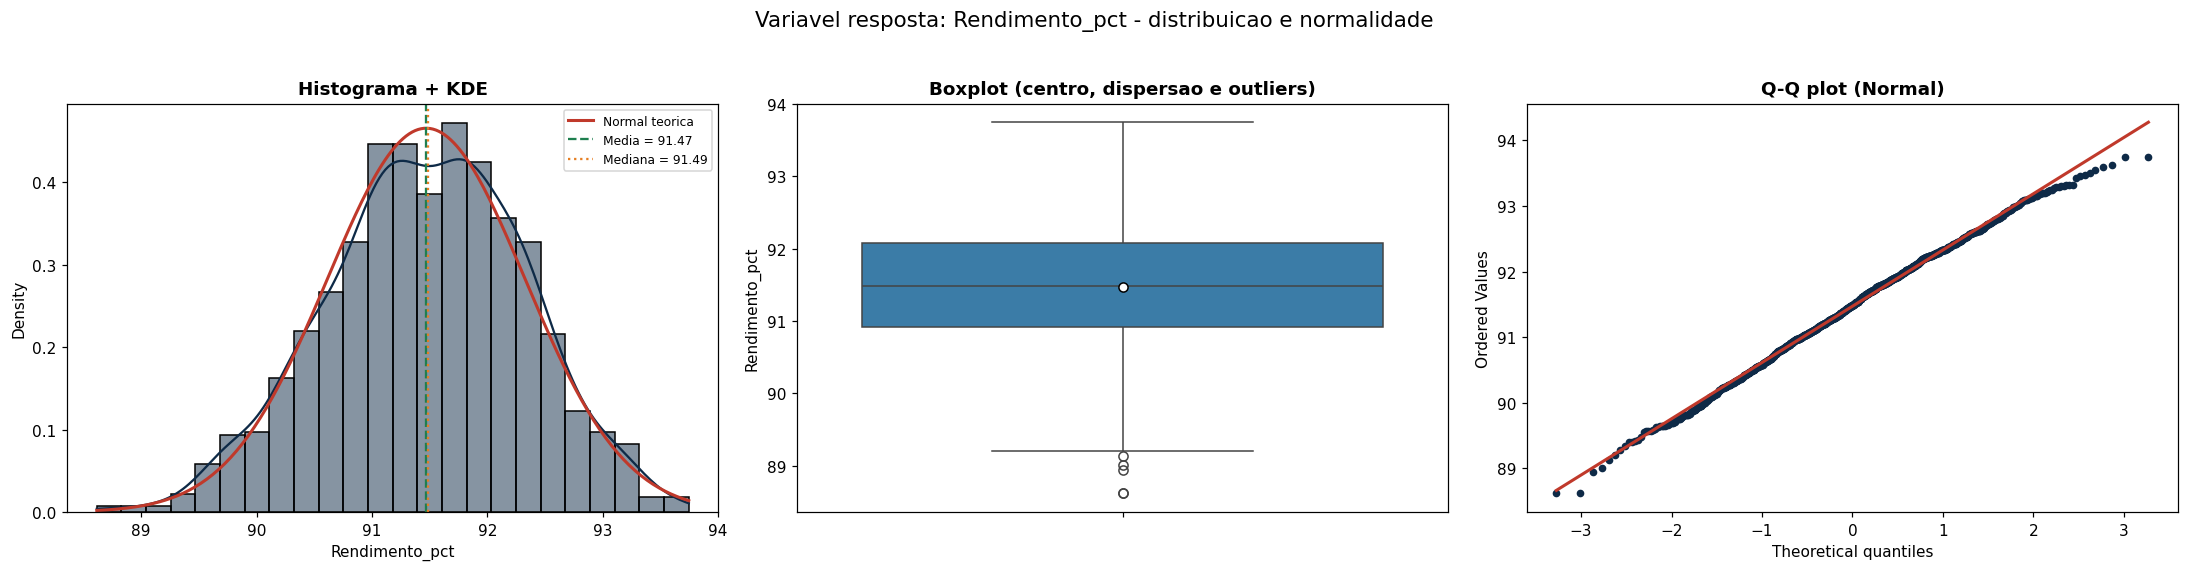

Estatisticas de Rendimento_pct:
  n          = 1300
  media      = 91.4702
  mediana    = 91.4855
  desvio     = 0.8573
  assimetria = -0.1504  (0 = simetrica)
  curtose    = -0.2021  (0 = normal/mesocurtica)

Testes de normalidade (H0: os dados seguem distribuicao Normal):
  Shapiro-Wilk        : W=0.9972  p=0.02109
  D'Agostino-Pearson  : K2=7.3604  p=0.02522

  Conclusao (alpha=0.05): a variavel NAO segue a Normal (p <= 0.05).
  -> Distribuicao nao-normal: considerar transformacao (ex.: log) na etapa de modelagem.


In [35]:
# Distribuicao e normalidade da variavel resposta (Y)
from scipy import stats

y_var = df[TARGET].dropna()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle(f"Variavel resposta: {TARGET} - distribuicao e normalidade", fontsize=14, y=1.03)

# 1) Histograma + KDE + curva Normal teorica
sns.histplot(y_var, kde=True, ax=axes[0], color="#0E2A47", stat="density")
mu, sigma = y_var.mean(), y_var.std()
xs = np.linspace(y_var.min(), y_var.max(), 200)
axes[0].plot(xs, stats.norm.pdf(xs, mu, sigma), color="#C0392B", lw=2, label="Normal teorica")
axes[0].axvline(mu, color="#1E7F4F", ls="--", lw=1.5, label=f"Media = {mu:.2f}")
axes[0].axvline(y_var.median(), color="#E67E22", ls=":", lw=1.5, label=f"Mediana = {y_var.median():.2f}")
axes[0].set_title("Histograma + KDE"); axes[0].legend(fontsize=8)

# 2) Boxplot
sns.boxplot(y=y_var, ax=axes[1], color="#2980B9", showmeans=True,
            meanprops={"marker":"o","markerfacecolor":"white","markeredgecolor":"black"})
axes[1].set_title("Boxplot (centro, dispersao e outliers)"); axes[1].set_ylabel(TARGET)

# 3) Q-Q plot (quantis observados x quantis teoricos da Normal)
stats.probplot(y_var, dist="norm", plot=axes[2])
axes[2].get_lines()[0].set_color("#0E2A47"); axes[2].get_lines()[0].set_markersize(4)
axes[2].get_lines()[1].set_color("#C0392B"); axes[2].get_lines()[1].set_lw(2)
axes[2].set_title("Q-Q plot (Normal)")

plt.tight_layout(); plt.show()

# ------------------------------------------------------------------
# Estatisticas descritivas e testes de normalidade
# ------------------------------------------------------------------
print(f"Estatisticas de {TARGET}:")
print(f"  n          = {len(y_var)}")
print(f"  media      = {mu:.4f}")
print(f"  mediana    = {y_var.median():.4f}")
print(f"  desvio     = {sigma:.4f}")
print(f"  assimetria = {stats.skew(y_var):+.4f}  (0 = simetrica)")
print(f"  curtose    = {stats.kurtosis(y_var):+.4f}  (0 = normal/mesocurtica)")

print("\nTestes de normalidade (H0: os dados seguem distribuicao Normal):")
# Shapiro-Wilk (recomendado ate ~5000 observacoes)
amostra = y_var.sample(5000, random_state=42) if len(y_var) > 5000 else y_var
W, p_sw = stats.shapiro(amostra)
print(f"  Shapiro-Wilk        : W={W:.4f}  p={p_sw:.4g}")
# D'Agostino-Pearson
k2, p_da = stats.normaltest(y_var)
print(f"  D'Agostino-Pearson  : K2={k2:.4f}  p={p_da:.4g}")

alpha = 0.05
normal = (p_sw > alpha) and (p_da > alpha)
print(f"\n  Conclusao (alpha={alpha}): a variavel {'PARECE Normal' if normal else 'NAO segue a Normal'} "
      f"(p {'>' if normal else '<='} {alpha}).")
if not normal:
    print("  -> Distribuicao nao-normal: considerar transformacao (ex.: log) na etapa de modelagem.")

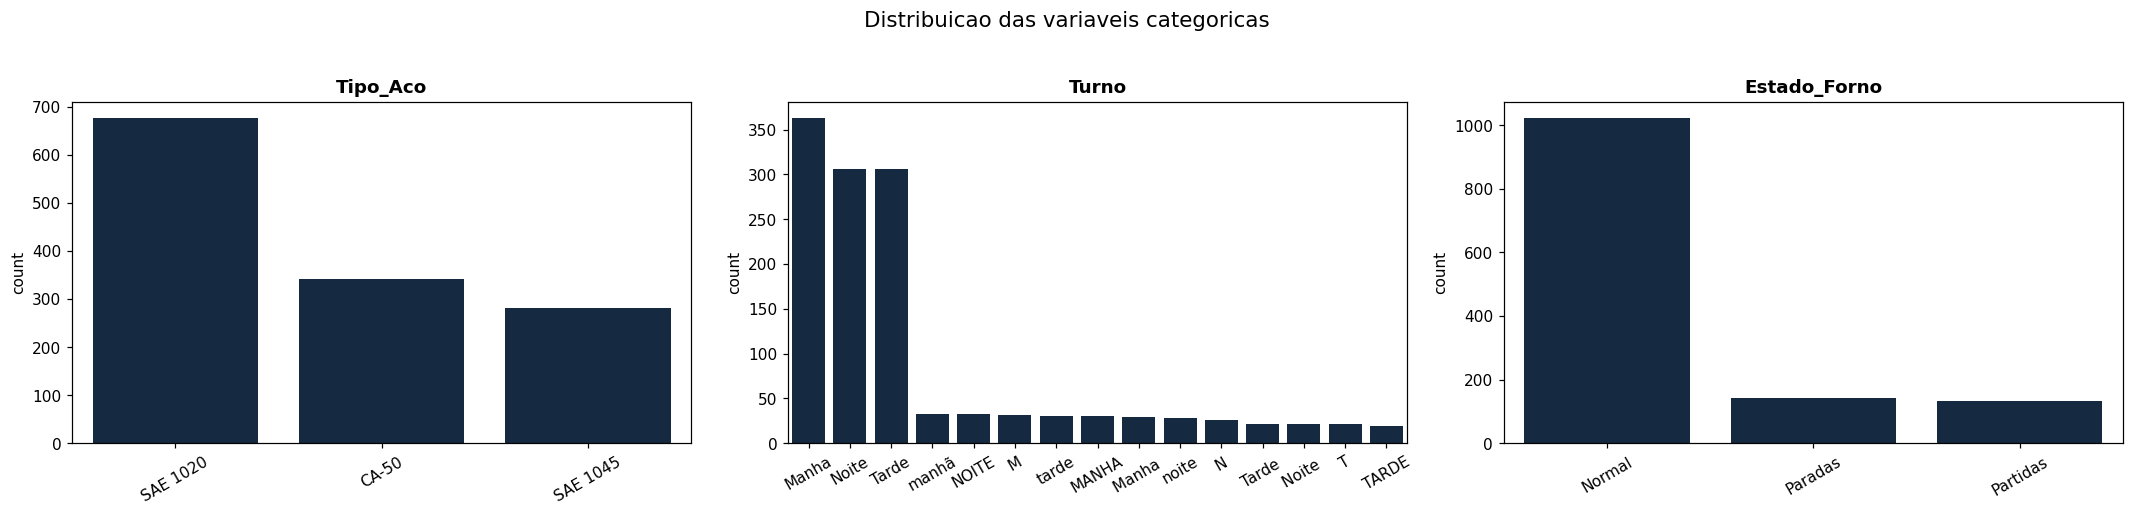

In [36]:
# Distribuicao das variaveis CATEGORICAS (dinamico)
if CAT_COLS:
    fig, axes = grade_subplots(len(CAT_COLS), ncols=3, larg=6.5, alt=4.5)
    fig.suptitle("Distribuicao das variaveis categoricas", fontsize=14, y=1.03)
    for ax, var in zip(axes, CAT_COLS):
        sns.countplot(ax=ax, x=var, data=df, color="#0E2A47",
                      order=df[var].value_counts().index)
        ax.set_title(var); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
    for ax in axes[len(CAT_COLS):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("Nao ha variaveis categoricas neste dataset.")

**Observação crítica — `Turno`:**

Note que o gráfico de `Turno` mostra **categorias repetidas**: "Noite", "NOITE", "noite", "N",
"Noite " (com espaço) aparecem separadamente, mas representam o **mesmo turno**!

Isso é um erro de cadastro clássico (digitação manual, sistemas diferentes). Se não corrigirmos,
o modelo trataria cada grafia como uma categoria distinta. **Vamos corrigir na etapa de limpeza.**


### **Variáveis Numéricas — Mix de Sucata**

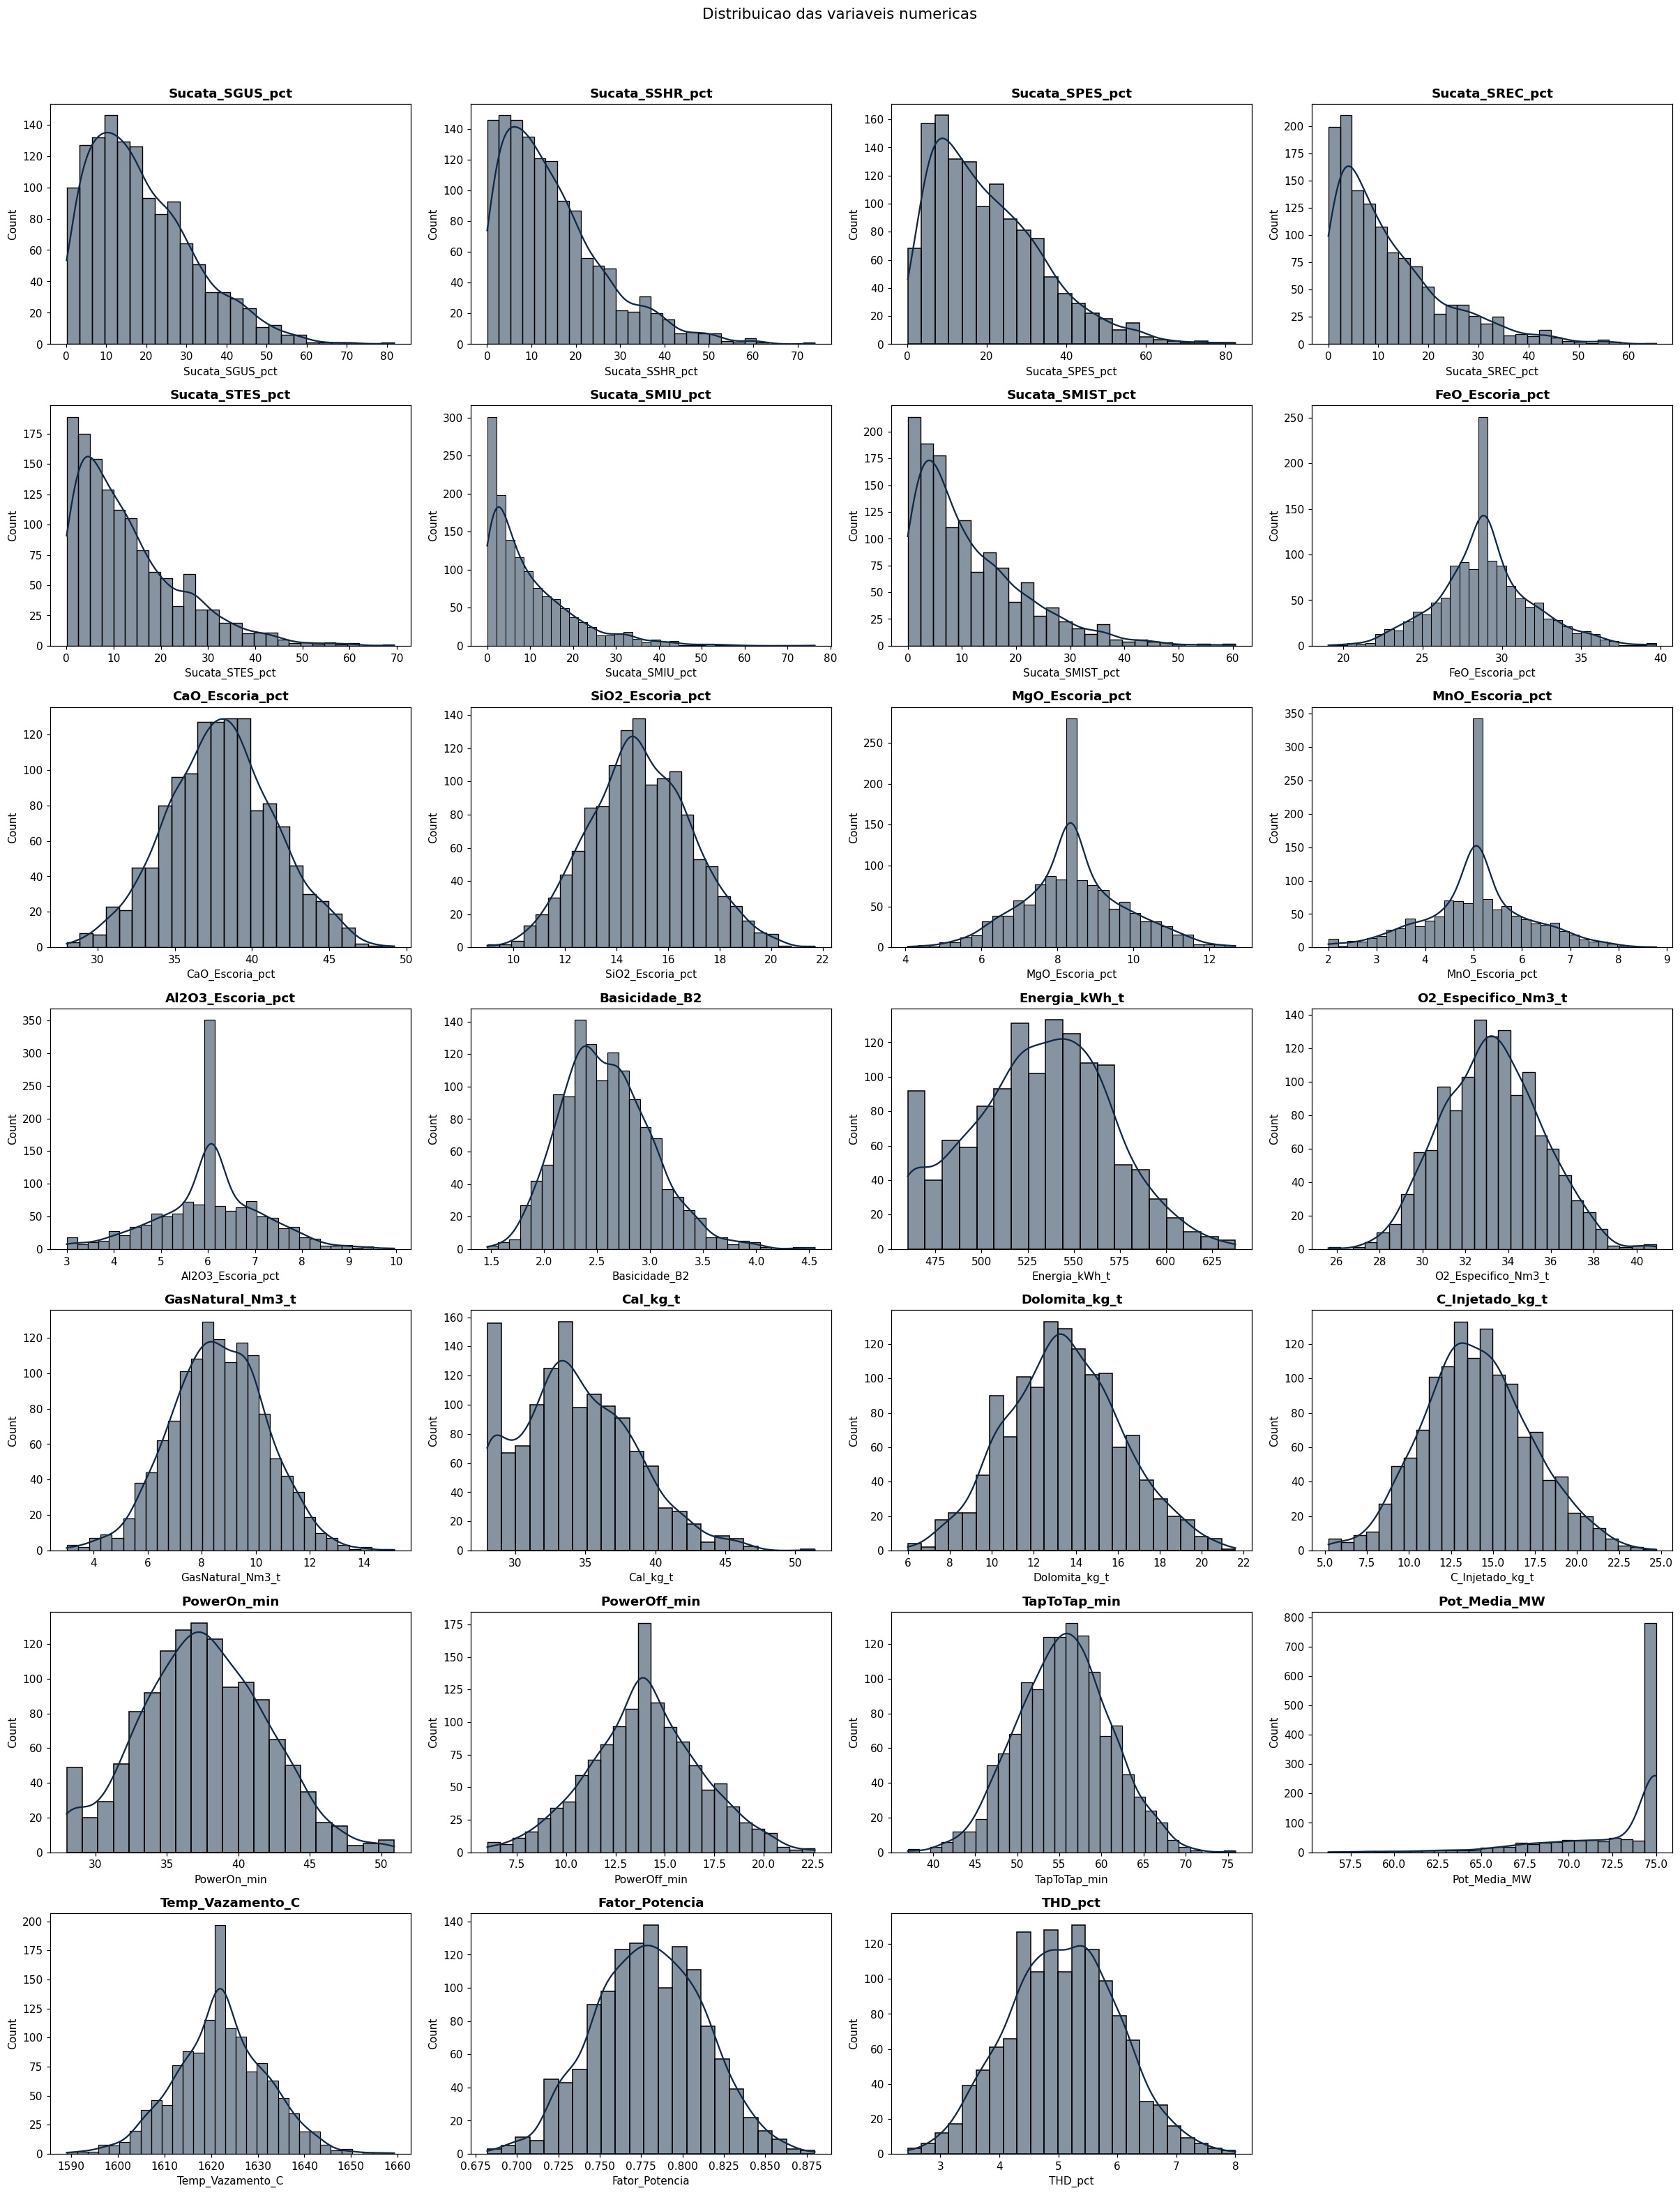

In [37]:
# Distribuicao de TODAS as variaveis numericas preditoras (dinamico)
plot_histogramas(NUM_COLS, "Distribuicao das variaveis numericas", cor="#0E2A47")

**Observações:**
- Cada tipo de sucata tem sua faixa típica de participação na carga, definida pela
  disponibilidade no pátio e pela receita de carregamento.
- A soma dos 7 tipos é sempre ~100% — isso é uma **restrição de soma fechada** (*closure*).
  Ela tem uma consequência estatística importante: os percentuais **não são independentes**
  (se um sobe, outro precisa descer). Veremos isso de novo na análise de multicolinearidade.


### **Variáveis Numéricas — Escória**

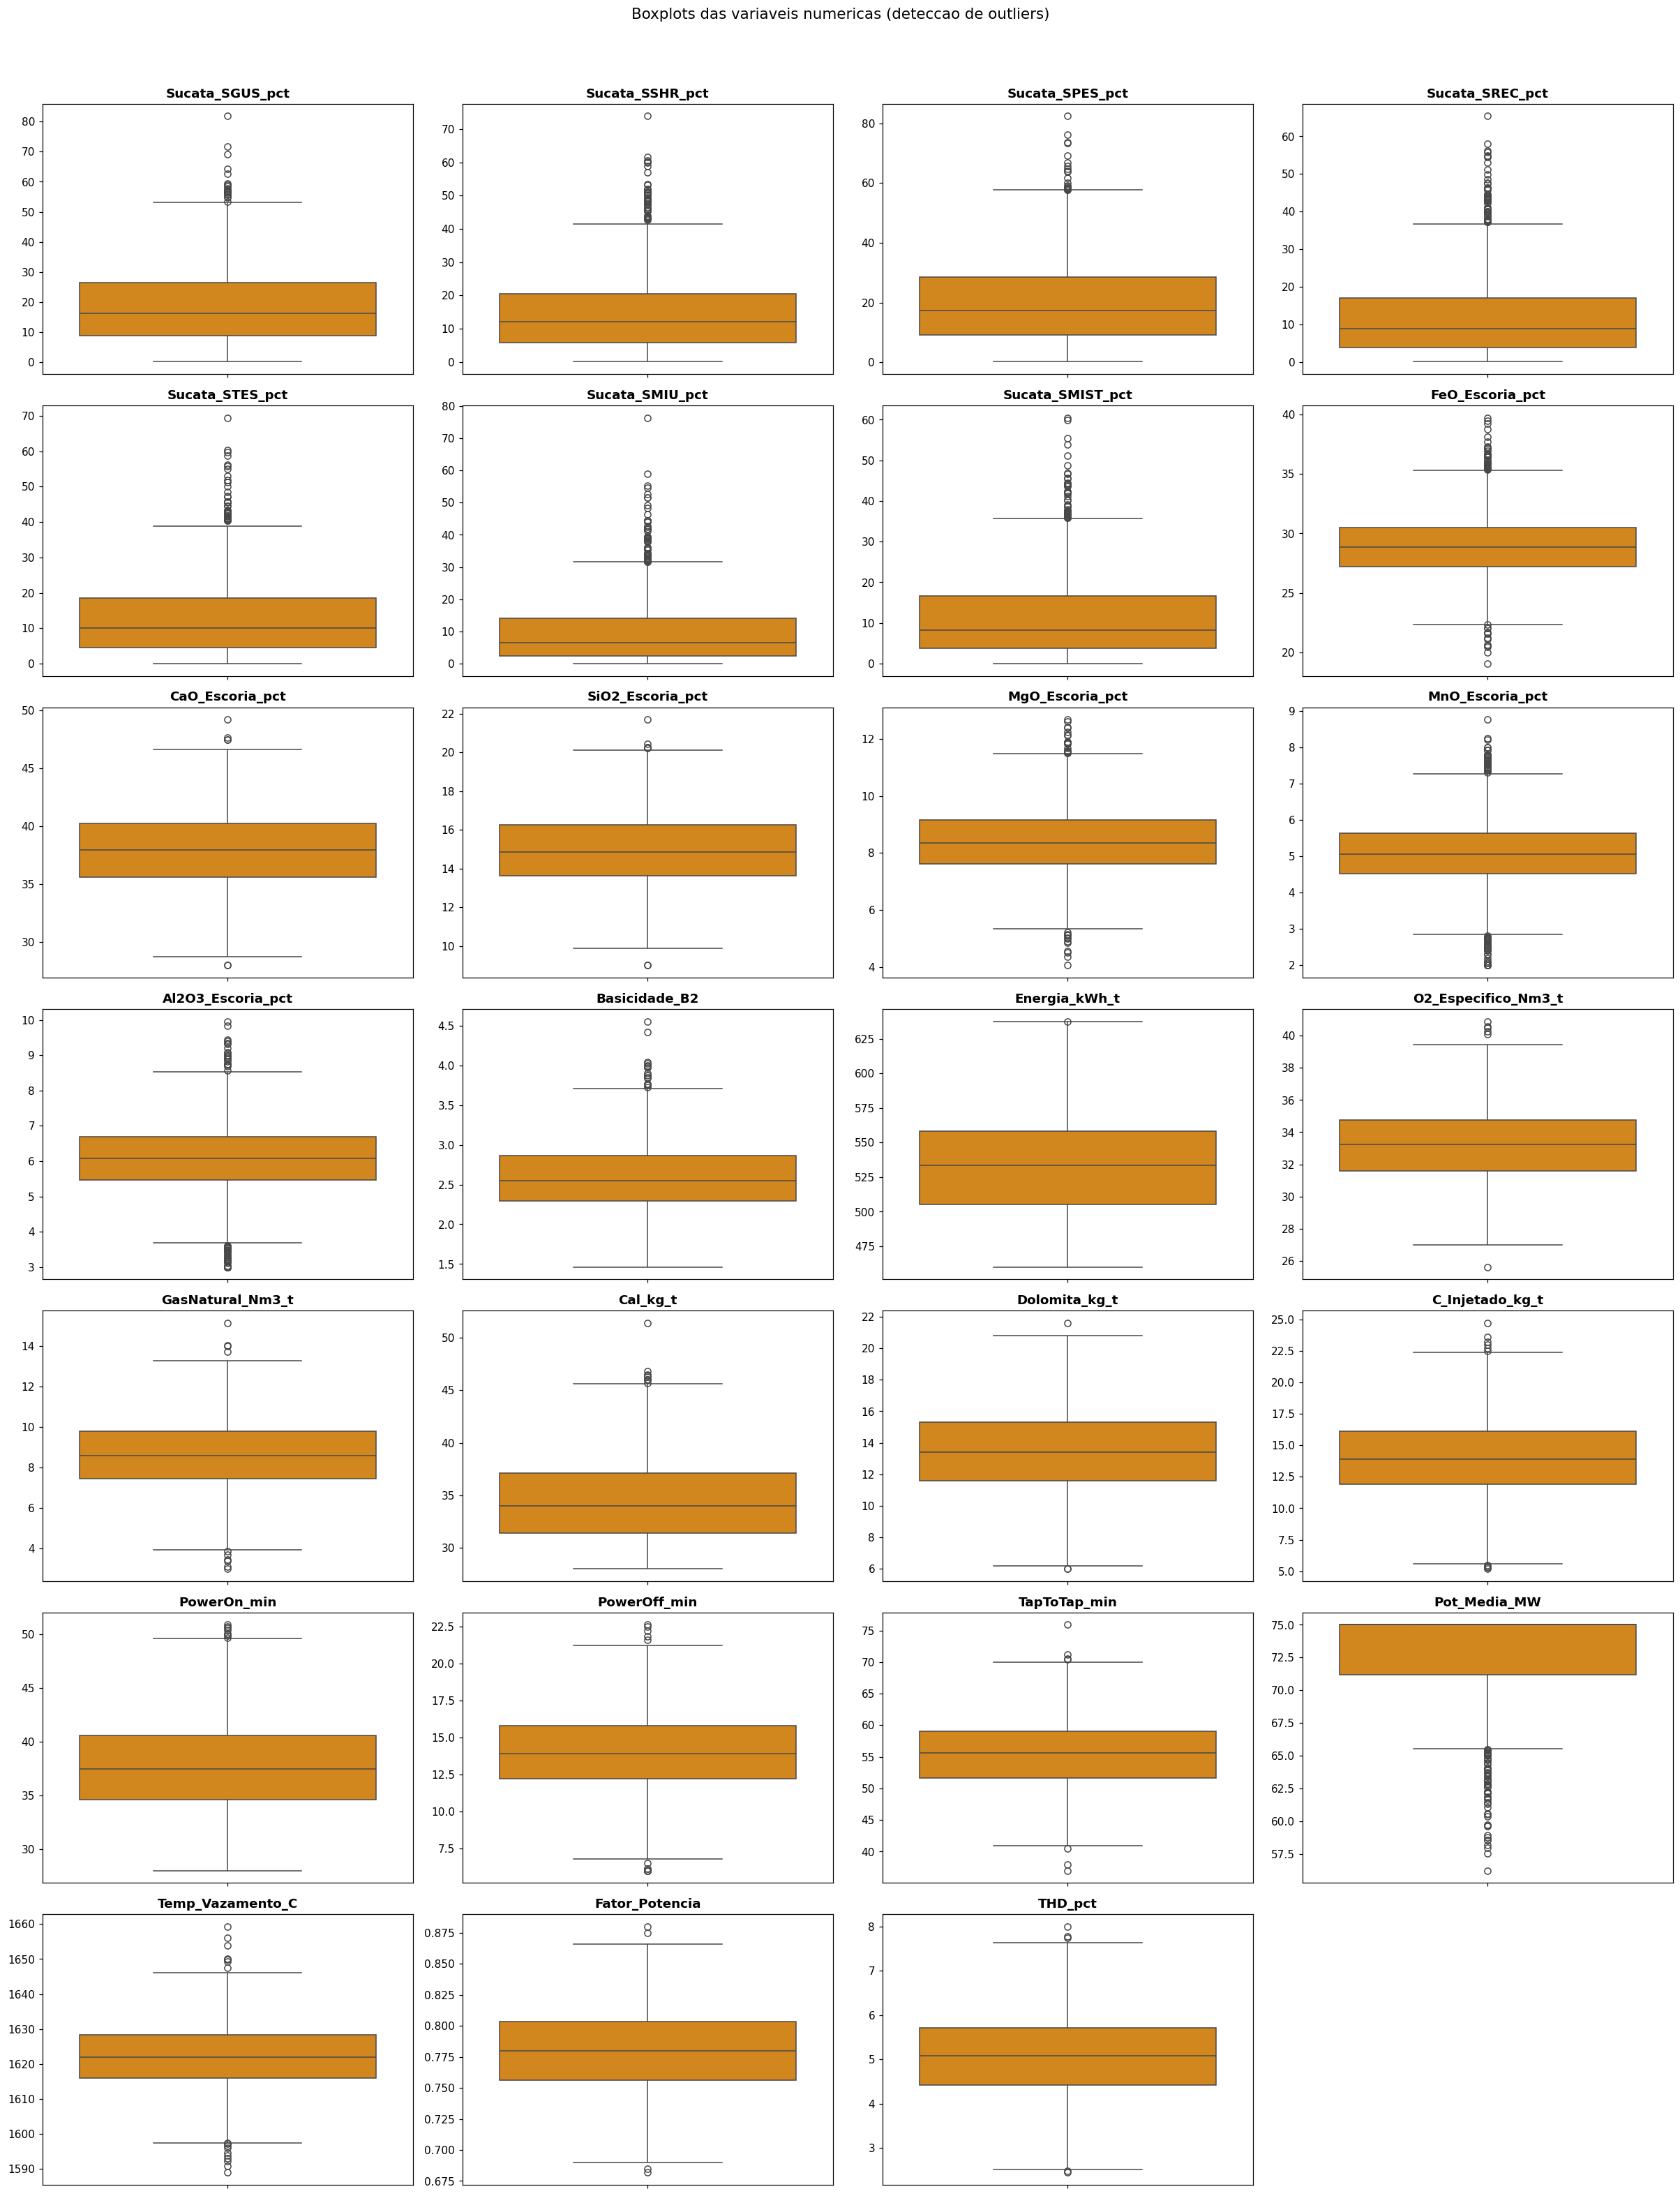

In [38]:
# Boxplots das variaveis numericas - visualizacao de outliers (dinamico)
if NUM_COLS:
    fig, axes = grade_subplots(len(NUM_COLS))
    fig.suptitle("Boxplots das variaveis numericas (deteccao de outliers)", fontsize=14, y=1.02)
    for ax, col in zip(axes, NUM_COLS):
        sns.boxplot(y=df[col], ax=ax, color="#F08C00")
        ax.set_title(col); ax.set_ylabel("")
    for ax in axes[len(NUM_COLS):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("Nao ha variaveis numericas preditoras neste dataset.")

**Observações:**
- **FeO:** distribuição aproximadamente normal com cauda à direita — corridas anormais
  (forno frio, sopro excessivo) elevam o FeO.
- **CaO e SiO₂:** distribuições normais, definindo a basicidade.
- **Basicidade B2 (CaO/SiO₂):** concentrada entre 2 e 3, típica de escória básica para
  desfosforação e proteção do refratário.
- **MgO:** relacionado à saturação do refratário de MgO-C (dolomita adicionada para preservar
  o revestimento).
- **MnO:** acompanha o nível de oxidação (correlacionado com FeO).


### **Variáveis Numéricas — Consumos e Operação**

In [39]:
# Resumo estatistico das variaveis numericas (dinamico)
print("Resumo estatistico das variaveis numericas (incluindo o alvo):")
df[NUM_COLS + [TARGET]].describe().T.round(3)

Resumo estatistico das variaveis numericas (incluindo o alvo):


,count,mean,std,min,25%,50%,75%,max
Sucata_SGUS_pct,1300.0,18.806,12.997,0.130,8.748,16.290,26.528,81.860
Sucata_SSHR_pct,1300.0,14.716,11.624,0.030,5.895,12.050,20.400,73.910
Sucata_SPES_pct,1300.0,20.234,13.821,0.180,9.182,17.315,28.632,82.450
Sucata_SREC_pct,1300.0,12.052,10.931,0.030,3.870,8.935,17.065,65.420
Sucata_STES_pct,1300.0,13.010,11.092,0.040,4.538,10.035,18.530,69.430
Sucata_SMIU_pct,1300.0,9.822,10.047,0.010,2.375,6.570,14.085,76.380
Sucata_SMIST_pct,1300.0,11.379,10.065,0.010,3.760,8.295,16.568,60.470
FeO_Escoria_pct,1300.0,28.922,2.979,19.060,27.220,28.850,30.465,39.720
CaO_Escoria_pct,1300.0,37.999,3.467,28.000,35.610,37.970,40.260,49.200
SiO2_Escoria_pct,1300.0,14.939,1.962,9.000,13.630,14.835,16.270,21.690


**Observações:**
- **Energia (kWh/t):** distribuição normal centrada em ~540 kWh/t, típica de FEA. Energia alta
  geralmente acompanha corridas problemáticas (mais FeO, forno frio).
- **O₂ e Gás Natural:** distribuições normais — fontes de energia química complementares.
- **Power On / Power Off:** o Power On é o tempo com arco ligado (fusão); o Power Off é o tempo
  parado (espera, carregamento, manutenção). O Tap-to-Tap é aproximadamente a soma dos dois.
- **Potência média e Temperatura:** bem comportadas, indicando operação padronizada.


---
## **Limpeza e Tratamento de Valores Faltantes**

### **1. Padronização da variável `Turno`**

Corrigimos as múltiplas grafias mapeando todas para a categoria canônica.


In [40]:
# Padronizacao de categorias com grafias inconsistentes (aplica-se a 'Turno' se existir)
import unicodedata

def _normaliza_texto(x):
    """Minusculo, sem acentos e sem espacos extras. Corrige mojibake comum (ex: manhÃ£)."""
    s = str(x).strip()
    # tenta corrigir texto lido com encoding errado (latin-1 <-> utf-8)
    try:
        s = s.encode('latin-1').decode('utf-8')
    except (UnicodeEncodeError, UnicodeDecodeError):
        pass
    s = unicodedata.normalize('NFKD', s).encode('ascii', 'ignore').decode('ascii')
    return s.strip().lower()

if 'Turno' in df.columns:
    def padronizar_turno(x):
        if pd.isna(x):
            return np.nan
        t = _normaliza_texto(x)            # ex: 'manha', 'manh', 'm', 'tarde', 'noite'
        if t.startswith('manh') or t == 'm':
            return 'Manha'
        if t.startswith('tard') or t == 't':
            return 'Tarde'
        if t.startswith('noit') or t == 'n':
            return 'Noite'
        return str(x).strip()              # mantem original se nao reconhecido

    print("ANTES:", sorted(df['Turno'].dropna().unique().tolist()))
    df["Turno"] = df["Turno"].apply(padronizar_turno)
    print("DEPOIS:", sorted(df['Turno'].dropna().unique().tolist()))
else:
    print("Coluna 'Turno' nao presente neste dataset - etapa de padronizacao ignorada.")

ANTES: ['M', 'MANHA', 'Manha', 'Manha ', 'N', 'NOITE', 'Noite', 'Noite ', 'T', 'TARDE', 'Tarde', 'Tarde ', 'manhã', 'noite', 'tarde']
DEPOIS: ['Manha', 'Noite', 'Tarde']


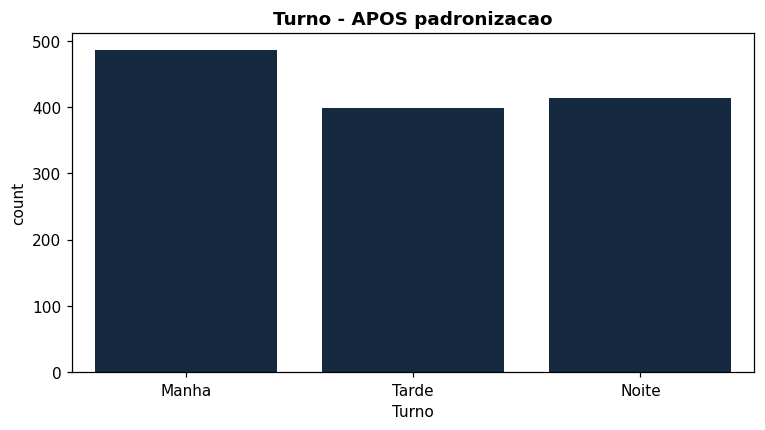

In [41]:
if 'Turno' in df.columns:
    fig = plt.figure(figsize=(8,4))
    ordem = [t for t in ["Manha","Tarde","Noite"] if t in df['Turno'].unique()]
    sns.countplot(x="Turno", data=df, color="#0E2A47", order=ordem or None)
    plt.title("Turno - APOS padronizacao"); plt.show()
else:
    print("Coluna 'Turno' nao presente - grafico ignorado.")

### **2. Investigando o padrão dos faltantes da escória**

Antes de imputar, é fundamental entender **por que** os dados faltam. Vamos verificar se as
corridas sem análise de escória têm algum perfil diferente das demais.


In [42]:
# Investigacao do padrao de valores faltantes (dinamico)
cols_com_falta = df.columns[df.isnull().any()].tolist()
print("Colunas com valores faltantes:", cols_com_falta if cols_com_falta else "Nenhuma")

if cols_com_falta:
    mask = df[cols_com_falta].isnull()
    print("\nQuantidade de faltantes por coluna:")
    print(mask.sum().to_string())

    fig = plt.figure(figsize=(12, max(2, 0.4 * len(cols_com_falta))))
    sns.heatmap(mask.head(80).T, cbar=False, cmap=["#E8EDF2","#C0392B"])
    plt.title("Mapa de faltantes (vermelho = faltante) - primeiras 80 linhas")
    plt.yticks(rotation=0); plt.xlabel("Linha"); plt.tight_layout(); plt.show()
else:
    print("Nao ha valores faltantes a investigar.")

Colunas com valores faltantes: Nenhuma
Nao ha valores faltantes a investigar.


**Observação:**
Os faltantes dos óxidos **não ocorrem todos juntos** — uma corrida pode ter FeO medido mas não
ter MnO, por exemplo. Isso indica falhas independentes de análise/apontamento, e não uma corrida
inteira sem amostragem. Estratégia: **imputar cada óxido pela sua mediana** (robusta a outliers).

> 💡 **Por que mediana e não média?** A mediana não é influenciada por valores extremos. Em
> variáveis de escória, que podem ter outliers de corridas anormais, a mediana preserva melhor
> o valor "típico".


In [43]:
# Imputacao de faltantes (dinamico): mediana p/ numericas, moda p/ categoricas
falt_antes = df.isnull().sum().sum()
print(f"Total de faltantes ANTES da imputacao: {falt_antes}")

if falt_antes > 0:
    for col in df.columns:
        if df[col].isnull().any():
            if pd.api.types.is_numeric_dtype(df[col]):
                df[col] = df[col].fillna(df[col].median())
            else:
                df[col] = df[col].fillna(df[col].mode(dropna=True).iloc[0])
    print(f"Total de faltantes APOS imputacao: {df.isnull().sum().sum()}")
else:
    print("Nenhum valor faltante - imputacao desnecessaria.")

Total de faltantes ANTES da imputacao: 0
Nenhum valor faltante - imputacao desnecessaria.


**Observação:**
A imputação pela mediana adiciona um pequeno pico no valor central, mas **preserva o formato
geral** da distribuição — não distorce a análise. Para ~14% de faltantes, esse é um tratamento
aceitável e transparente.


---
## **Análise Exploratória — Bivariada**

Agora investigamos as **relações entre as variáveis e o rendimento**.
- Para **variáveis categóricas**: gráficos de barras (rendimento médio por categoria).
- Para **variáveis numéricas**: gráficos de dispersão (scatter).

### **Categóricas × Rendimento**


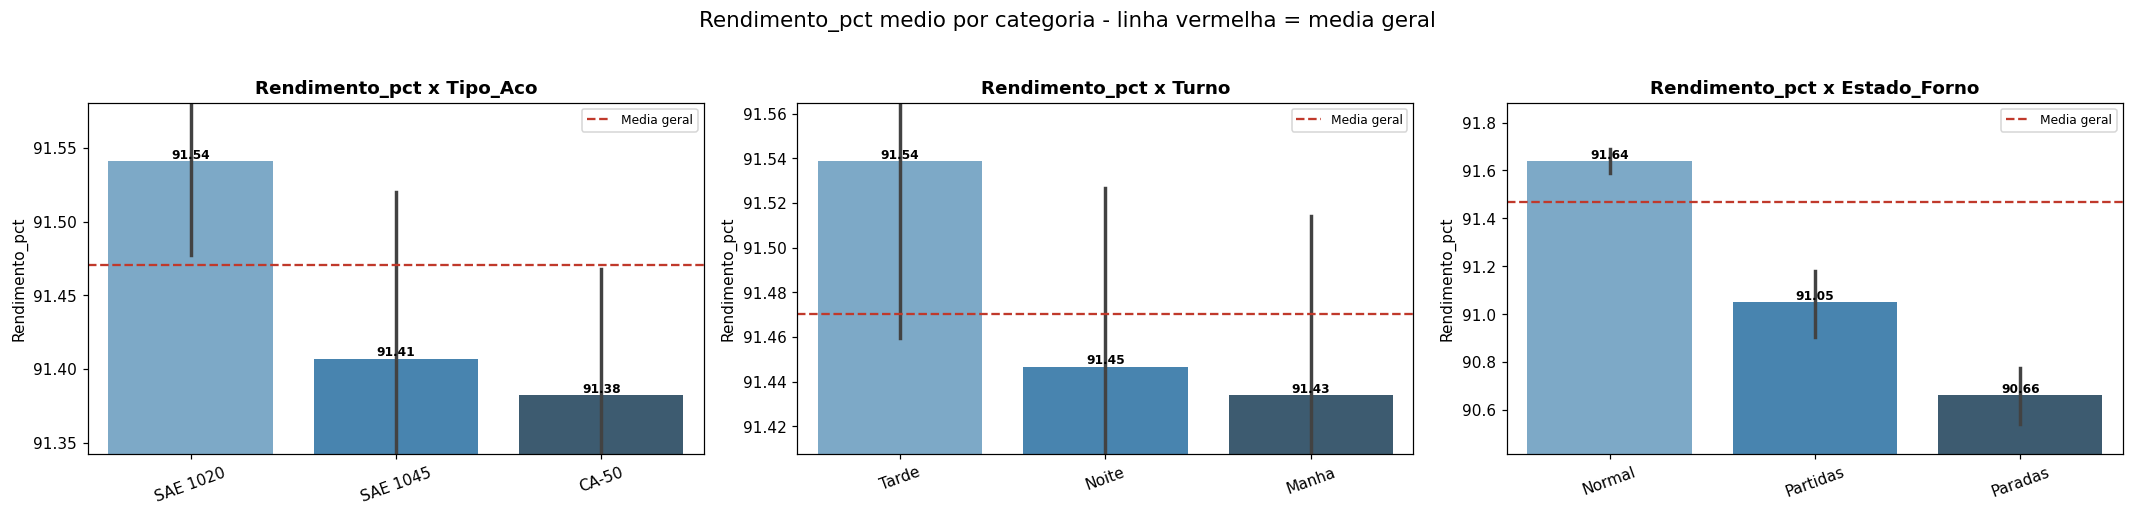

Media de Rendimento_pct por categoria (ordenado do MAIOR para o MENOR):

--- Tipo_Aco ---
           media    n
Tipo_Aco             
SAE 1020  91.541  677
SAE 1045  91.407  282
CA-50     91.382  341
   -> MAIOR rendimento: 'SAE 1020' (91.54) | MENOR: 'CA-50' (91.38)

--- Turno ---
        media    n
Turno             
Tarde  91.539  399
Noite  91.447  414
Manha  91.434  487
   -> MAIOR rendimento: 'Tarde' (91.54) | MENOR: 'Manha' (91.43)

--- Estado_Forno ---
               media     n
Estado_Forno              
Normal        91.638  1023
Partidas      91.049   134
Paradas       90.661   143
   -> MAIOR rendimento: 'Normal' (91.64) | MENOR: 'Paradas' (90.66)



In [44]:
# Rendimento (Y) medio por categoria (dinamico)
# Eixo Y com ZOOM na faixa real das medias -> destaca as diferencas entre categorias
if CAT_COLS:
    fig, axes = grade_subplots(len(CAT_COLS), ncols=3, larg=6.5, alt=4.5)
    fig.suptitle(f"{TARGET} medio por categoria - linha vermelha = media geral", fontsize=14, y=1.03)
    media = df[TARGET].mean()
    for ax, var in zip(axes, CAT_COLS):
        # Ordena da MAIOR para a MENOR media (barra mais alta = maior rendimento)
        medias_cat = df.groupby(var)[TARGET].mean().sort_values(ascending=False)
        ordem = medias_cat.index
        sns.barplot(x=var, y=TARGET, data=df, ax=ax, estimator="mean",
                    order=ordem, palette="Blues_d", errorbar=("ci", 95))
        ax.axhline(media, color="#C0392B", ls="--", lw=1.5, label="Media geral")

        # Zoom dinamico: faixa das medias por categoria (+ media geral) com margem
        lo = min(medias_cat.min(), media)
        hi = max(medias_cat.max(), media)
        span = hi - lo
        margem = span * 0.25 if span > 0 else max(abs(hi) * 0.01, 0.05)
        ax.set_ylim(lo - margem, hi + margem)

        # Rotulo do valor medio em cada barra (na ordem exata das barras)
        for i, v in enumerate(medias_cat.values):
            ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

        ax.set_title(f"{TARGET} x {var}"); ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)
        ax.legend(fontsize=8)
    for ax in axes[len(CAT_COLS):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

    # Tabela numerica (prova de que grafico e numeros batem)
    print("Media de", TARGET, "por categoria (ordenado do MAIOR para o MENOR):\n")
    for var in CAT_COLS:
        tab = df.groupby(var)[TARGET].agg(['mean', 'count']).sort_values('mean', ascending=False)
        tab.columns = ['media', 'n']
        print(f"--- {var} ---")
        print(tab.round(3).to_string())
        menor = tab.index[-1]
        maior = tab.index[0]
        print(f"   -> MAIOR rendimento: '{maior}' ({tab['media'].iloc[0]:.2f}) | "
              f"MENOR: '{menor}' ({tab['media'].iloc[-1]:.2f})\n")
else:
    print("Nao ha variaveis categoricas para cruzar com o alvo.")

**Observações:**
- **Estado_Forno:** o rendimento cai conforme o forno se afasta da condição estável:
  *Normal* (~91,6%) > *Pré-parada* (~91,0%) > *Pós-parada* (~90,7%). A diferença entre *Normal*
  e *Pós-parada* é de **~1 p.p.** — forno frio exige mais energia/O₂, gerando mais FeO.
  **Variável relevante** (a tabela impressa pela célula confirma a direção).
- **Tipo_Aco:** diferenças pequenas; o CA-50 tende a render um pouco menos (maior teor de
  elementos oxidáveis).
- **Turno:** após a limpeza, os três turnos têm rendimento médio similar — não parece ser um
  fator determinante (o que faz sentido: o processo deveria ser robusto ao turno).

### **Numéricas × Rendimento — Dispersão**

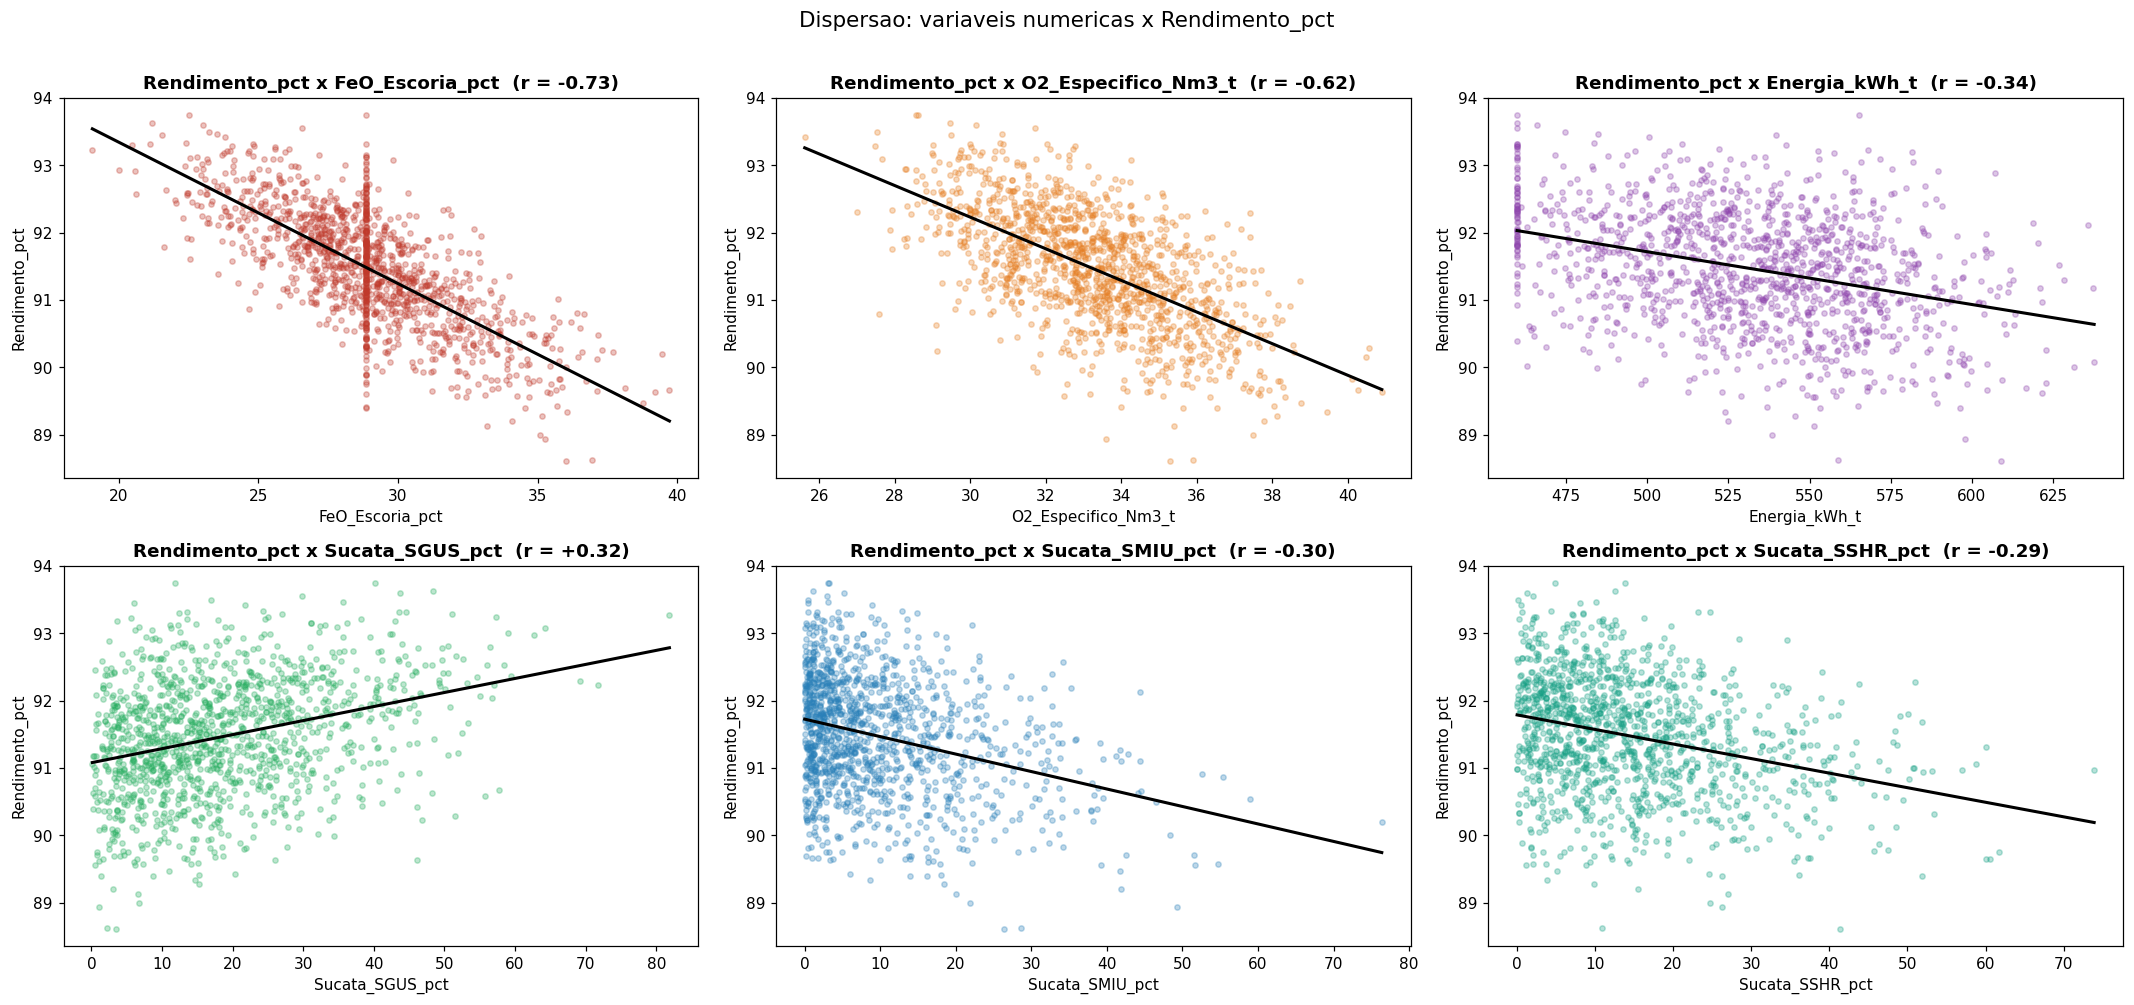

In [45]:
# Dispersao das variaveis numericas mais correlacionadas com o alvo (dinamico)
corr_y = df[NUM_COLS + [TARGET]].corr()[TARGET].drop(TARGET)
top_vars = corr_y.abs().sort_values(ascending=False).head(6).index.tolist()
cores = ["#C0392B","#E67E22","#8E44AD","#27AE60","#2980B9","#16A085"]

if top_vars:
    fig, axes = grade_subplots(len(top_vars), ncols=3, larg=6.5, alt=4.5)
    fig.suptitle(f"Dispersao: variaveis numericas x {TARGET}", fontsize=14, y=1.01)
    for ax, var, cor in zip(axes, top_vars, cores):
        ax.scatter(df[var], df[TARGET], alpha=0.3, s=12, color=cor)
        b, a = np.polyfit(df[var], df[TARGET], 1)
        xs = np.array([df[var].min(), df[var].max()])
        ax.plot(xs, a + b*xs, color="black", lw=2)
        r = df[[var, TARGET]].corr().iloc[0,1]
        ax.set_title(f"{TARGET} x {var}  (r = {r:+.2f})")
        ax.set_xlabel(var); ax.set_ylabel(TARGET)
    for ax in axes[len(top_vars):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("Nao ha variaveis numericas para dispersao.")

**Observações:**
- **FeO × Rendimento:** relação negativa forte e linear — cada +1% de FeO reduz ~0,15 p.p. de
  rendimento. **Driver número 1.**
- **O₂ específico × Rendimento:** negativa moderada (sopro excessivo oxida o banho).
- **Energia × Rendimento:** negativa — corridas que consomem mais energia tendem a ser as mais
  problemáticas (mais FeO, mais perda).
- **Carbono injetado × Rendimento:** positiva — o carbono reduz o FeO da escória (C + FeO → Fe + CO).
- **% gusa (SGUS) × Rendimento:** positiva — o gusa é ferro metálico de alta pureza.
- **Basicidade B2 × Rendimento:** positiva fraca — escória mais básica favorece o rendimento.


---
## **Análise de Correlação (foco do estudo)**

A matriz de correlação é a ferramenta central da EDA para um problema de regressão. Ela mostra:
1. **Quais variáveis se relacionam com o rendimento** (última linha/coluna);
2. **Quais variáveis se relacionam entre si** (multicolinearidade — crucial para o modelo).

### **Matriz de correlação completa**


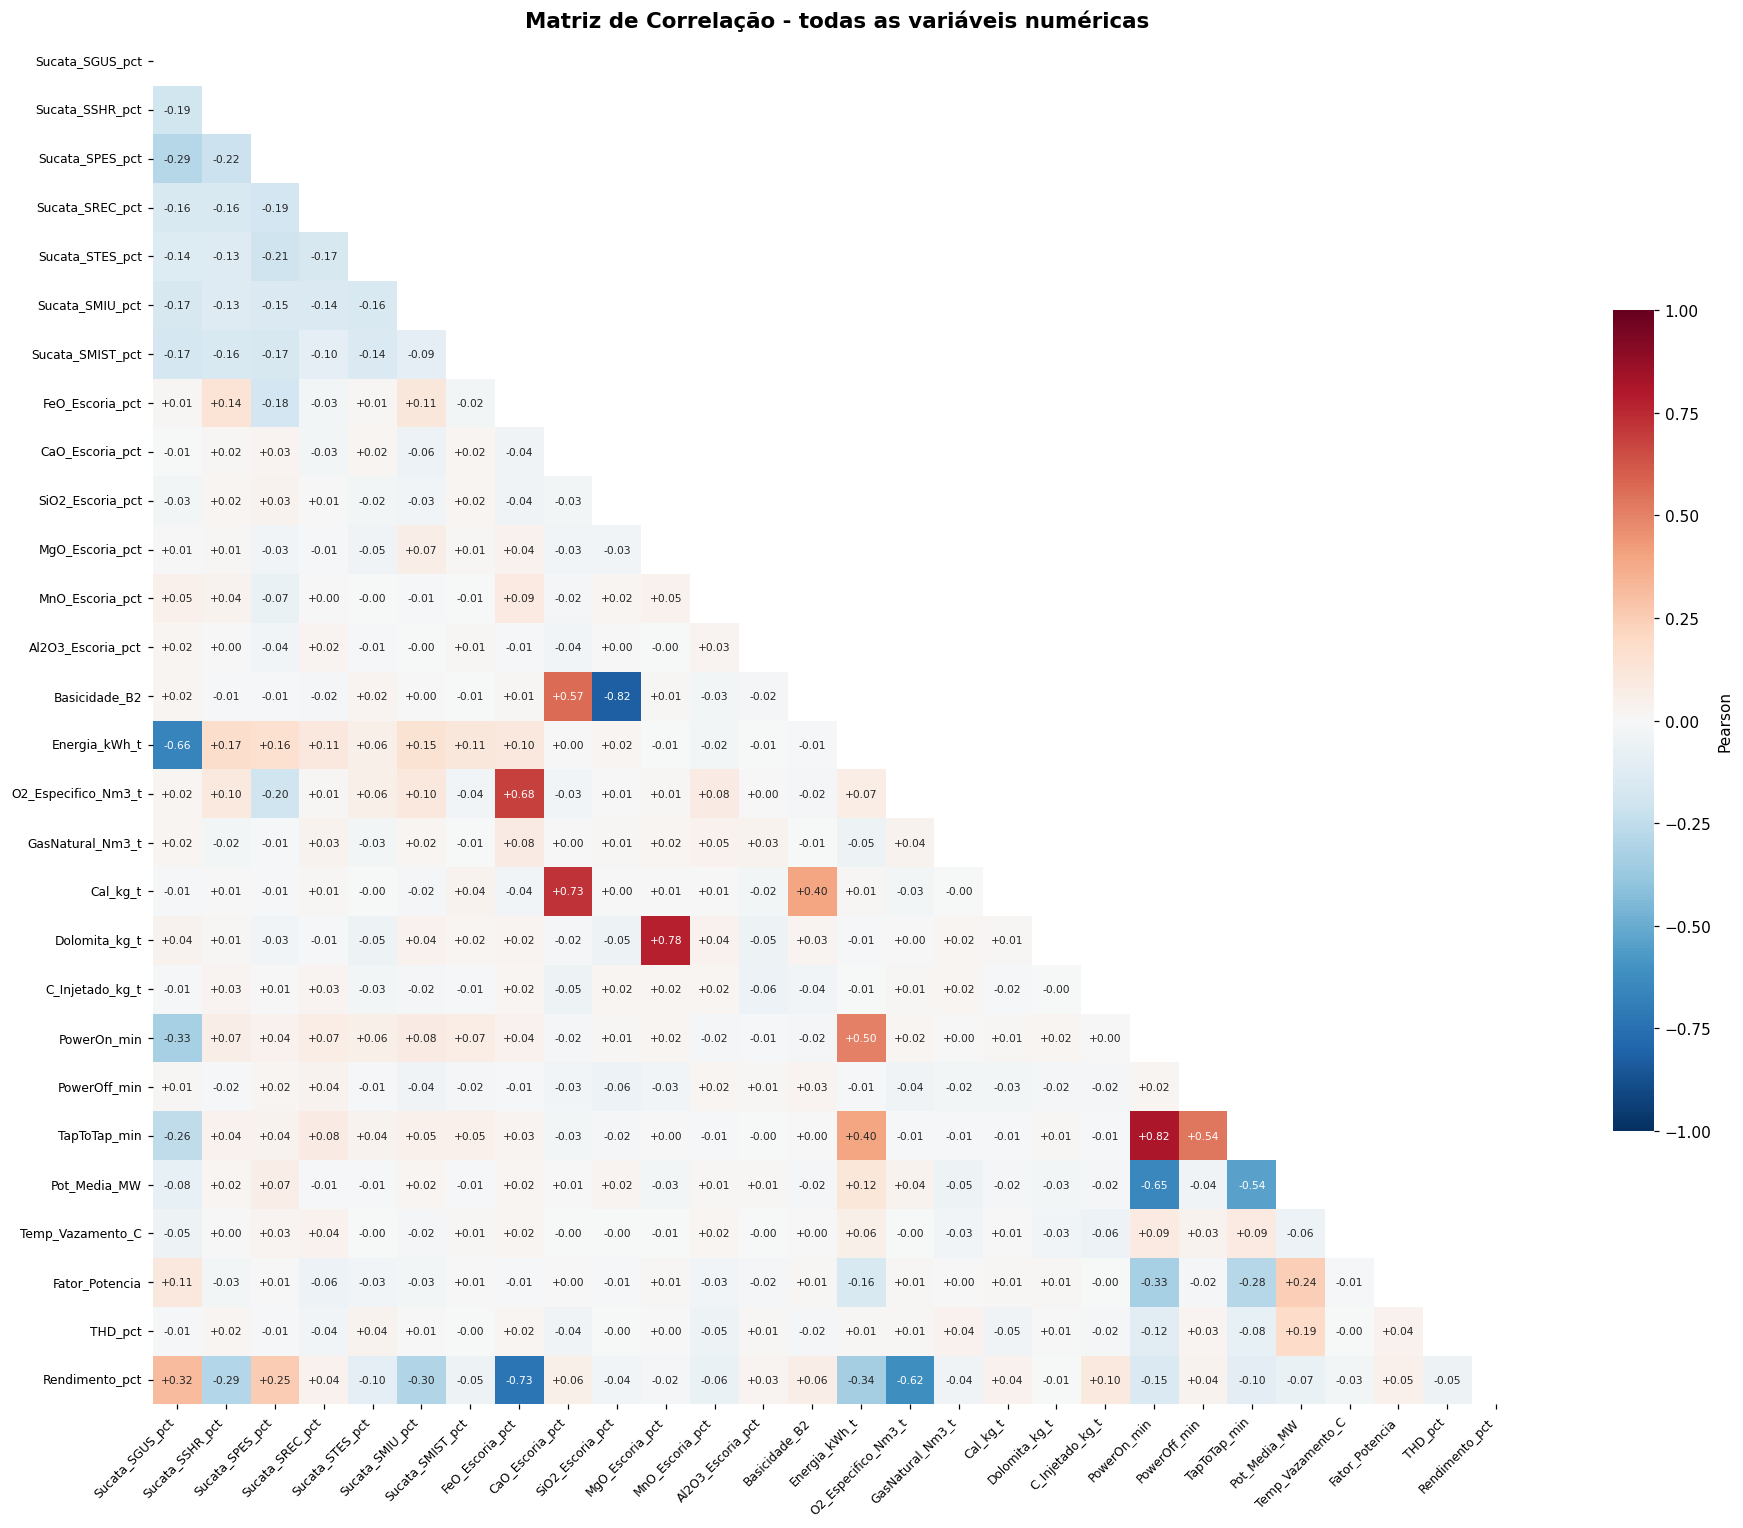

In [46]:
num_df = df.select_dtypes("number")
corr = num_df.corr()

fig = plt.figure(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))  # mostrar só triângulo inferior
sns.heatmap(corr, mask=mask, annot=True, fmt="+.2f", cmap="RdBu_r", vmin=-1, vmax=1,
            annot_kws={"size":7}, square=True, cbar_kws={"shrink":0.6,"label":"Pearson"})
plt.title("Matriz de Correlação - todas as variáveis numéricas", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=8); plt.yticks(fontsize=8)
plt.tight_layout(); plt.show()

**Como ler esta matriz (didática):**
- **Azul forte (+):** correlação positiva — as variáveis crescem juntas.
- **Vermelho forte (−):** correlação negativa — quando uma sobe, a outra desce.
- **Branco (~0):** sem relação linear.

Procuramos dois tipos de informação: a **última linha** (relação com o rendimento) e os
**blocos coloridos fora da diagonal** (variáveis correlacionadas entre si = multicolinearidade).


### **Correlação de cada variável com o Rendimento (ranking)**

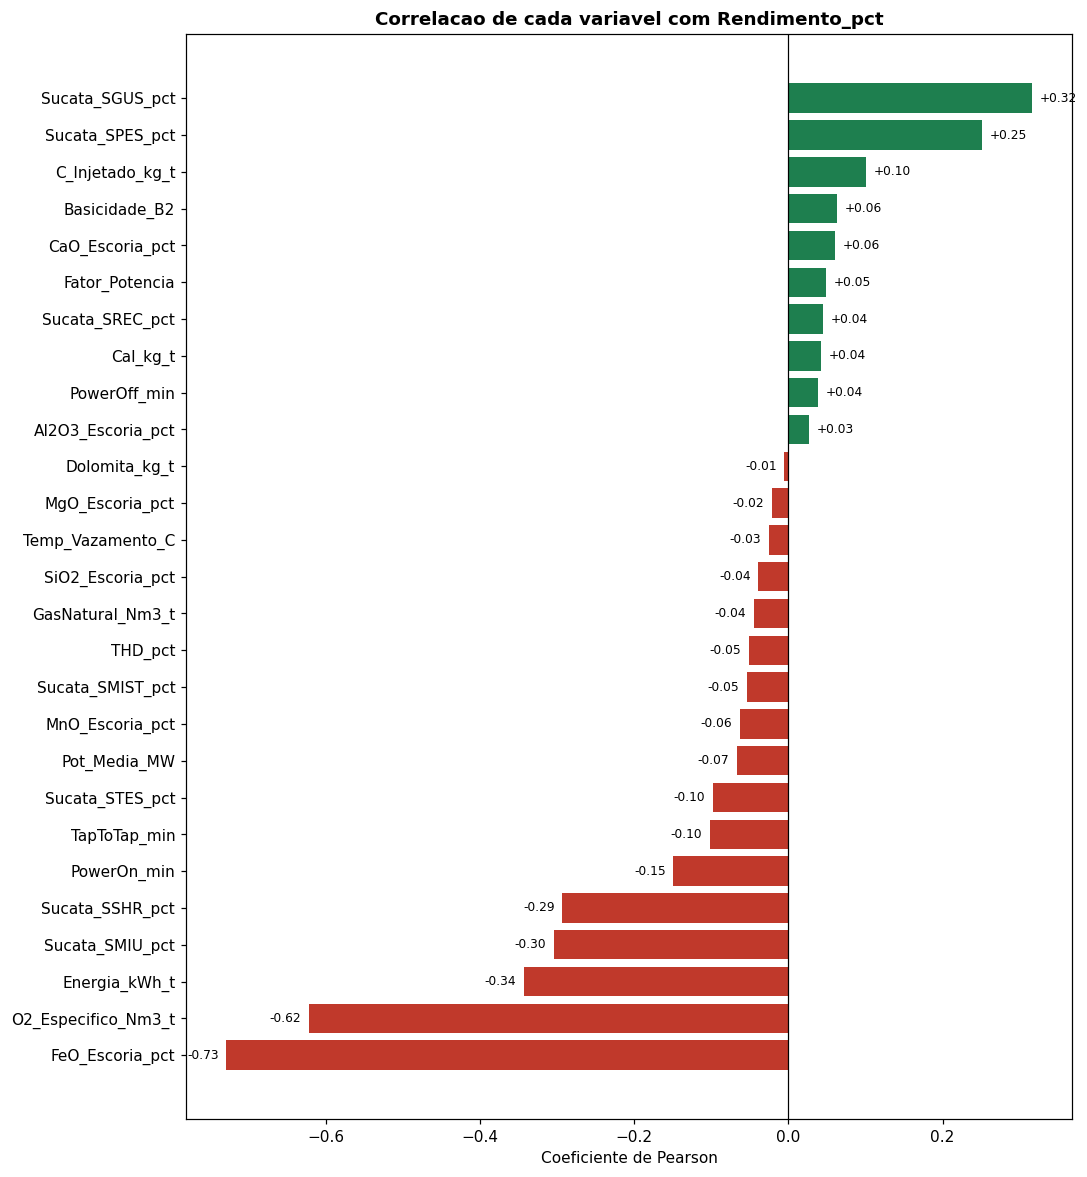

Top 5 correlacoes NEGATIVAS (reduzem o alvo):
FeO_Escoria_pct       -0.729
O2_Especifico_Nm3_t   -0.622
Energia_kWh_t         -0.343
Sucata_SMIU_pct       -0.304
Sucata_SSHR_pct       -0.293
Name: Rendimento_pct, dtype: float64

Top 5 correlacoes POSITIVAS (aumentam o alvo):
CaO_Escoria_pct    0.060
Basicidade_B2      0.063
C_Injetado_kg_t    0.101
Sucata_SPES_pct    0.251
Sucata_SGUS_pct    0.316
Name: Rendimento_pct, dtype: float64


In [47]:
corr_rend = corr[TARGET].drop(TARGET).sort_values()

fig = plt.figure(figsize=(10, max(4, 0.4 * len(corr_rend))))
cores = ["#C0392B" if v < 0 else "#1E7F4F" for v in corr_rend.values]
plt.barh(corr_rend.index, corr_rend.values, color=cores)
plt.axvline(0, color="black", lw=0.8)
plt.title(f"Correlacao de cada variavel com {TARGET}")
plt.xlabel("Coeficiente de Pearson")
for i, v in enumerate(corr_rend.values):
    plt.text(v + (0.01 if v>=0 else -0.01), i, f"{v:+.2f}",
             va="center", ha="left" if v>=0 else "right", fontsize=8)
plt.tight_layout(); plt.show()

print("Top 5 correlacoes NEGATIVAS (reduzem o alvo):")
print(corr_rend.head(5).round(3))
print("\nTop 5 correlacoes POSITIVAS (aumentam o alvo):")
print(corr_rend.tail(5).round(3))

**Observações:**
- **Maiores correlações negativas:** FeO, O₂ específico, Energia, MnO — todas ligadas à
  **oxidação** do banho. Quanto mais oxidante a corrida, menor o rendimento.
- **Maiores correlações positivas:** % gusa (SGUS), carbono injetado, basicidade, sucata pesada
  — ligadas a **carga de qualidade** e **controle da escória**.
- Variáveis elétricas (THD, fator de potência) e tempos têm correlação fraca — provavelmente
  não entrarão no modelo final.


### **Investigando a multicolinearidade (relações entre preditores)**

Esta é a parte mais importante para quem vai construir um modelo de regressão. Variáveis muito
correlacionadas entre si causam **coeficientes instáveis e não interpretáveis**.

Vamos destacar os pares de variáveis com correlação forte entre si (|r| > 0,6):


In [48]:
# Pares de variaveis (excluindo a resposta) com |correlacao| alta
corr_pred = num_df.drop(columns=TARGET).corr()
pares = []
for i in range(len(corr_pred.columns)):
    for j in range(i+1, len(corr_pred.columns)):
        r = corr_pred.iloc[i,j]
        if abs(r) > 0.6:
            pares.append((corr_pred.columns[i], corr_pred.columns[j], round(r,3)))

pares_df = pd.DataFrame(pares, columns=["Variavel A","Variavel B","Correlacao"])
if len(pares_df):
    pares_df = pares_df.reindex(pares_df["Correlacao"].abs().sort_values(ascending=False).index)
    print("Pares de variaveis fortemente correlacionados entre si (|r| > 0,6):\n")
    print(pares_df.to_string(index=False))
else:
    print("Nenhum par de variaveis com |r| > 0,6 (multicolinearidade baixa).")

Pares de variaveis fortemente correlacionados entre si (|r| > 0,6):

      Variavel A          Variavel B  Correlacao
SiO2_Escoria_pct       Basicidade_B2      -0.821
     PowerOn_min        TapToTap_min       0.819
 MgO_Escoria_pct       Dolomita_kg_t       0.776
 CaO_Escoria_pct            Cal_kg_t       0.726
 FeO_Escoria_pct O2_Especifico_Nm3_t       0.680
 Sucata_SGUS_pct       Energia_kWh_t      -0.664
     PowerOn_min        Pot_Media_MW      -0.654


**Observações metalúrgicas (interpretando a multicolinearidade):**
- **FeO ↔ O₂ específico:** sopro excessivo de O₂ é a causa direta do FeO alto. São o mesmo
  fenômeno (oxidação) medido de duas formas.
- **FeO ↔ Energia:** corridas mais instaveis e de menor potencia exigem maior consumo de energia e oxigênio
- **FeO ↔ MnO:** o MnO acompanha o FeO (ambos são óxidos do banho oxidado).
- **CaO / SiO₂ ↔ Basicidade B2:** a basicidade **é calculada** a partir desses dois — colinearidade
  por construção (não faz sentido manter os três no modelo).
- **PowerOn / TapToTap:** o tap-to-tap inclui o power on — são parcialmente redundantes.
- **Mix de sucata:** os 7 percentuais somam 100% → quando um sobe, outro desce (soma fechada).

> 🎯 **Conclusão para a modelagem:** de cada grupo de variáveis "que dizem a mesma coisa",
> manteremos apenas **uma representante** — a mais interpretável e controlável pela operação.
> Isso será feito objetivamente pelo VIF.


---
## **Modelagem — Regressão Linear (consequência da EDA)**

Com a EDA concluída, a modelagem é quase uma formalização do que já entendemos.
Mantemos esta seção **enxuta e objetiva**: separação treino/teste, remoção de
multicolinearidade (VIF) e de variáveis não significativas (p-valor).

### **Separação Treino × Teste (70/30)**

O modelo nunca pode "ver" os dados de teste durante o treino — só assim avaliamos honestamente
a capacidade de generalizar para novas corridas.


In [49]:
# Features e resposta (dinamico)
features = [c for c in df.columns if c != TARGET]
X_raw = df[features]
y = df[TARGET]

# Define se a transformacao log e aplicavel (alvo estritamente positivo)
USAR_LOG = bool((y > 0).all())
print(f"Transformacao log no alvo: {'SIM' if USAR_LOG else 'NAO (alvo tem valores <= 0)'}")

# One-Hot Encoding das categoricas
X_enc = pd.get_dummies(X_raw, drop_first=True)
X_enc.columns = X_enc.columns.str.replace(" ","_",regex=False).str.replace("-","_",regex=False)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y, test_size=0.30, random_state=42)
for d in [X_train, X_test, y_train, y_test]:
    d.reset_index(drop=True, inplace=True)

# Escalonamento (fit SO no treino!)
scaler = MinMaxScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X_enc.columns)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=X_enc.columns)

print(f"Treino: {len(X_train)} linhas | Teste: {len(X_test)} linhas")
print(f"Total de features (com dummies): {X_enc.shape[1]}")

Transformacao log no alvo: SIM
Treino: 910 linhas | Teste: 390 linhas
Total de features (com dummies): 33


### **Remoção de variáveis não significativas (Backward Elimination, p > 0,05)**

In [50]:
# Transformacao do alvo (log se aplicavel - estabiliza variancia)
y_train_t = np.log(y_train) if USAR_LOG else y_train.copy()
y_test_t  = np.log(y_test)  if USAR_LOG else y_test.copy()

while True:
    modelo = sm.OLS(y_train_t, X_iter).fit()
    pvals = modelo.pvalues.drop("const")
    if pvals.max() <= 0.05 or len(X_iter.columns) <= 3:
        break
    X_iter = X_iter.drop(pvals.idxmax(), axis=1)

ols_final = modelo
print(f"Modelo final: {len([c for c in X_iter.columns if c!='const'])} variaveis significativas")
print(ols_final.summary())

Modelo final: 14 variaveis significativas
                            OLS Regression Results                            
Dep. Variable:         Rendimento_pct   R-squared:                       0.807
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     266.9
Date:                Sat, 13 Jun 2026   Prob (F-statistic):          1.04e-307
Time:                        16:42:02   Log-Likelihood:                 3708.0
No. Observations:                 910   AIC:                            -7386.
Df Residuals:                     895   BIC:                            -7314.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

**Observações:**
- Todas as variáveis remanescentes têm **p-valor < 0,05** e **VIF ≤ 5**.
- Os sinais dos coeficientes são **coerentes com a metalurgia**: FeO/O₂/Energia negativos
  (oxidação), gusa/carbono positivos (carga de qualidade e redução).
- O modelo é a tradução estatística de tudo o que vimos na EDA.


---
## **Avaliação do Modelo**

Verificamos R² no treino, na validação cruzada e no teste — os três devem ser próximos
(sinal de boa generalização, sem overfitting).


In [51]:
# R2 treino
r2_tr = ols_final.rsquared

# CV-10
cv = cross_val_score(LinearRegression(), X_iter, y_train_t, cv=10, scoring="r2")

# Teste (dados nunca vistos)
X_test_c = sm.add_constant(X_test_s)[X_iter.columns]
pred_t = ols_final.predict(X_test_c)
r2_te = r2_score(y_test_t, pred_t)

print("="*45)
print(f"  R2 Treino   = {r2_tr:.4f}")
print(f"  R2 CV-10    = {cv.mean():.4f}  (+/- {cv.std()*2:.4f})")
print(f"  R2 Teste    = {r2_te:.4f}")
print("="*45)
if abs(r2_tr - r2_te) < 0.05:
    print("  Modelo BEM generalizado (treino ~ teste).")
print(f"\n  O modelo explica ~{r2_te*100:.0f}% da variacao de {TARGET} em dados novos.")

  R2 Treino   = 0.8068
  R2 CV-10    = 0.7917  (+/- 0.0733)
  R2 Teste    = 0.7879
  Modelo BEM generalizado (treino ~ teste).

  O modelo explica ~79% da variacao de Rendimento_pct em dados novos.


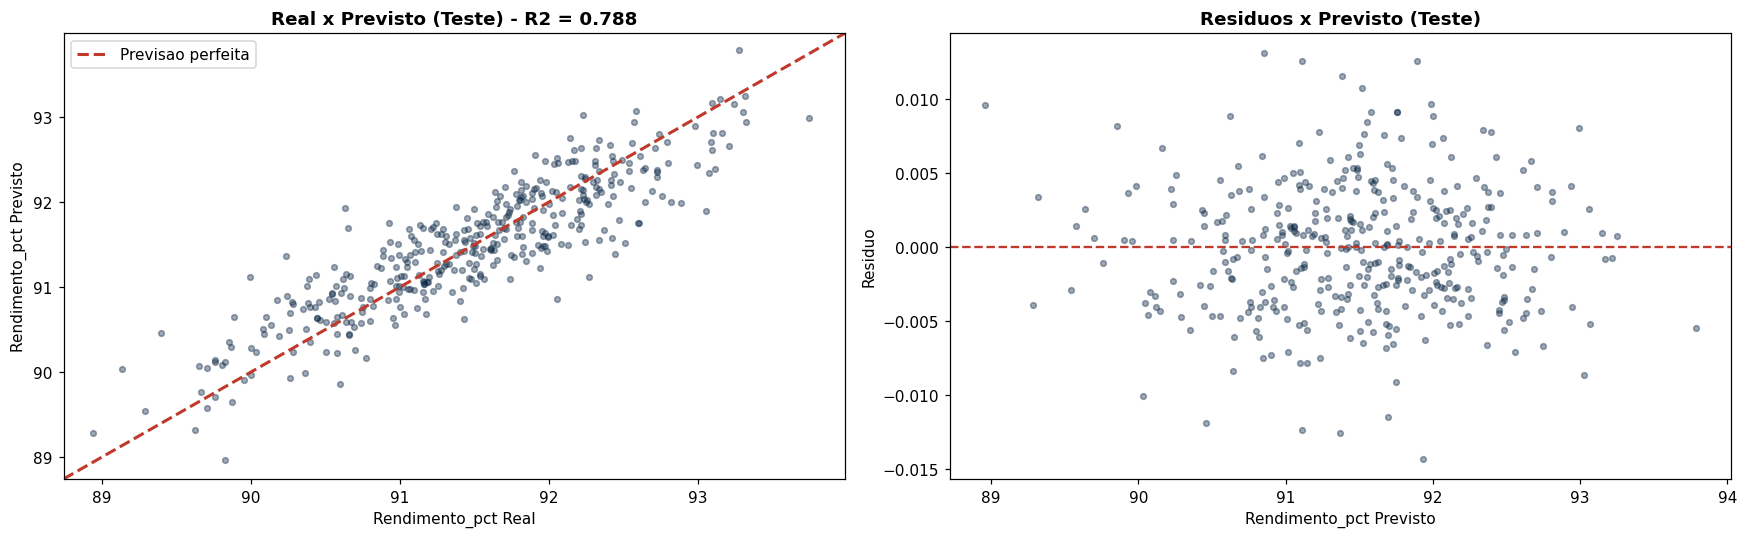

In [52]:
# Real x Previsto no teste
pred_orig = np.exp(pred_t) if USAR_LOG else pred_t
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].scatter(y_test, pred_orig, alpha=0.4, s=14, color="#0E2A47")
lim = (min(y_test.min(),pred_orig.min())-0.2, max(y_test.max(),pred_orig.max())+0.2)
axes[0].plot(lim, lim, color="#C0392B", lw=2, ls="--", label="Previsao perfeita")
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel(f"{TARGET} Real"); axes[0].set_ylabel(f"{TARGET} Previsto")
axes[0].set_title(f"Real x Previsto (Teste) - R2 = {r2_te:.3f}"); axes[0].legend()

residuos = y_test_t - pred_t
axes[1].scatter(pred_orig, residuos, alpha=0.4, s=14, color="#0E2A47")
axes[1].axhline(0, color="#C0392B", lw=1.5, ls="--")
axes[1].set_xlabel(f"{TARGET} Previsto"); axes[1].set_ylabel("Residuo")
axes[1].set_title("Residuos x Previsto (Teste)")
plt.tight_layout(); plt.show()

### **Importância das variáveis do modelo final**

Como as preditoras foram **padronizadas (0–1)** antes do ajuste, a **magnitude dos coeficientes**
é diretamente comparável e representa o **impacto de cada variável** sobre o alvo. O gráfico abaixo
ordena as variáveis remanescentes (após VIF + Backward) por importância, com a **cor** indicando o
**sentido** do efeito (verde = aumenta o rendimento, vermelho = reduz) e o **p-valor** anotado.

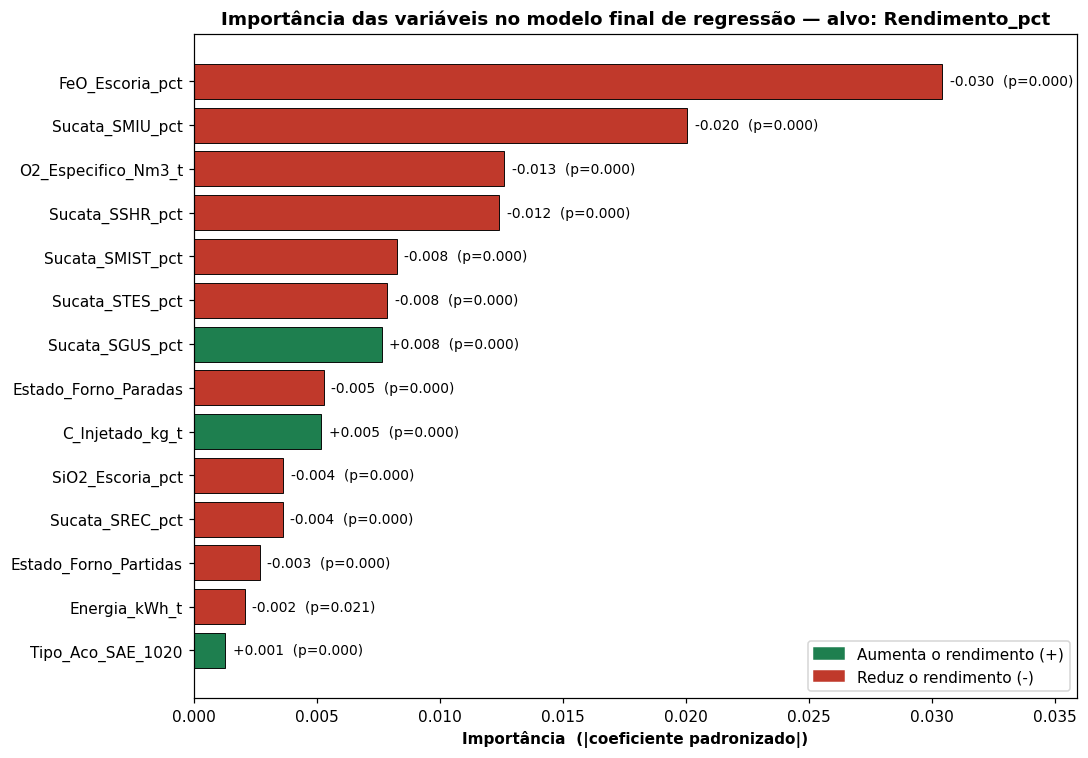

Variáveis do modelo final ordenadas por importância:
                         coef  pvalue
FeO_Escoria_pct       -0.0304  0.0000
Sucata_SMIU_pct       -0.0201  0.0000
O2_Especifico_Nm3_t   -0.0126  0.0000
Sucata_SSHR_pct       -0.0124  0.0000
Sucata_SMIST_pct      -0.0082  0.0000
Sucata_STES_pct       -0.0079  0.0000
Sucata_SGUS_pct        0.0076  0.0000
Estado_Forno_Paradas  -0.0053  0.0000
C_Injetado_kg_t        0.0052  0.0000
SiO2_Escoria_pct      -0.0036  0.0000
Sucata_SREC_pct       -0.0036  0.0002
Estado_Forno_Partidas -0.0027  0.0000
Energia_kWh_t         -0.0021  0.0209
Tipo_Aco_SAE_1020      0.0013  0.0000


In [55]:
# ==================================================================
# IMPORTANCIA DAS VARIAVEIS DO MODELO FINAL (apos VIF + Backward)
# Coeficientes padronizados (features em escala 0-1) -> comparaveis
# ==================================================================
coefs = ols_final.params.drop("const")
pvals = ols_final.pvalues.drop("const")

imp = pd.DataFrame({"coef": coefs, "pvalue": pvals})
imp["abs"] = imp["coef"].abs()
imp = imp.sort_values("abs", ascending=True)            # menor -> maior (barh)

cores = ["#1E7F4F" if c > 0 else "#C0392B" for c in imp["coef"]]

fig, ax = plt.subplots(figsize=(10, max(4, 0.5 * len(imp))))
barras = ax.barh(imp.index, imp["abs"], color=cores, edgecolor="black", linewidth=0.6)

# Anotacao: valor do coeficiente (com sinal) + p-valor
for barra, (nome, linha) in zip(barras, imp.iterrows()):
    ax.text(barra.get_width() + imp["abs"].max() * 0.01,
            barra.get_y() + barra.get_height() / 2,
            f"{linha['coef']:+.3f}  (p={linha['pvalue']:.3f})",
            va="center", ha="left", fontsize=9)

ax.set_xlim(0, imp["abs"].max() * 1.18)
ax.set_xlabel("Importância  (|coeficiente padronizado|)", fontweight="bold")
ax.set_title(f"Importância das variáveis no modelo final de regressão — alvo: {TARGET}",
             fontweight="bold")

# Legenda de sentido do efeito
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#1E7F4F", label="Aumenta o rendimento (+)"),
                   Patch(color="#C0392B", label="Reduz o rendimento (-)")],
          loc="lower right", frameon=True)

plt.tight_layout()
plt.savefig("fig_importancia_variaveis_modelo_final.png", bbox_inches="tight", dpi=150)
plt.show()

# Tabela ordenada (maior -> menor importancia)
print("Variáveis do modelo final ordenadas por importância:")
print(imp.sort_values("abs", ascending=False)[["coef", "pvalue"]].round(4).to_string())

---
## **Conclusões e Recomendações**

### **O que a EDA revelou:**

1. **Qualidade de dados é o primeiro entregável.** Encontramos e corrigimos inconsistências de
   cadastro no `Turno` e tratamos ~14-22% de faltantes nas análises de escória — sem isso,
   qualquer modelo seria inválido.

2. **O rendimento é governado pela oxidação.** As variáveis mais correlacionadas (FeO, O₂,
   Energia, MnO) descrevem o mesmo fenômeno: quanto mais oxidante a corrida, maior a perda de
   ferro para a escória.

3. **Multicolinearidade tem significado físico.** FeO↔O₂↔Energia, CaO/SiO₂↔Basicidade e o mix de
   sucata (soma fechada) são grupos que "dizem a mesma coisa". O VIF nos ajudou a manter uma
   representante de cada grupo.

4. **Alavancas positivas:** carga de gusa, carbono injetado e basicidade adequada melhoram o
   rendimento.

### **Recomendações para a operação:**

- **Controle do FeO/O₂:** revisar a curva de sopro de oxigênio — é a alavanca de maior impacto.
- **Injeção de carbono:** garantir injeção adequada para reduzir o FeO da escória (formação de CO).
- **Carga metálica:** priorizar gusa e sucata pesada quando a meta de rendimento for crítica.
- **Corridas Pós-parada:** protocolo específico de reaquecimento e ajuste de carga.

### **Sobre a sequência (DMAIC):**
A EDA **gera e prioriza hipóteses** com base em correlações. A **comprovação causal** das
alavancas (ex.: reduzir O₂ realmente aumenta o rendimento?) deve ser feita com **experimento
planejado (DOE)** — o próximo passo natural deste projeto.

---
*Case Study - EDA e Regressão Linear Aplicadas à Aciaria*
*Treinamento: Controle e Otimização de Processos - Estatística Aplicada à Aciaria*


<!-- Célula movida para antes das Conclusões. Pode apagar esta célula. -->


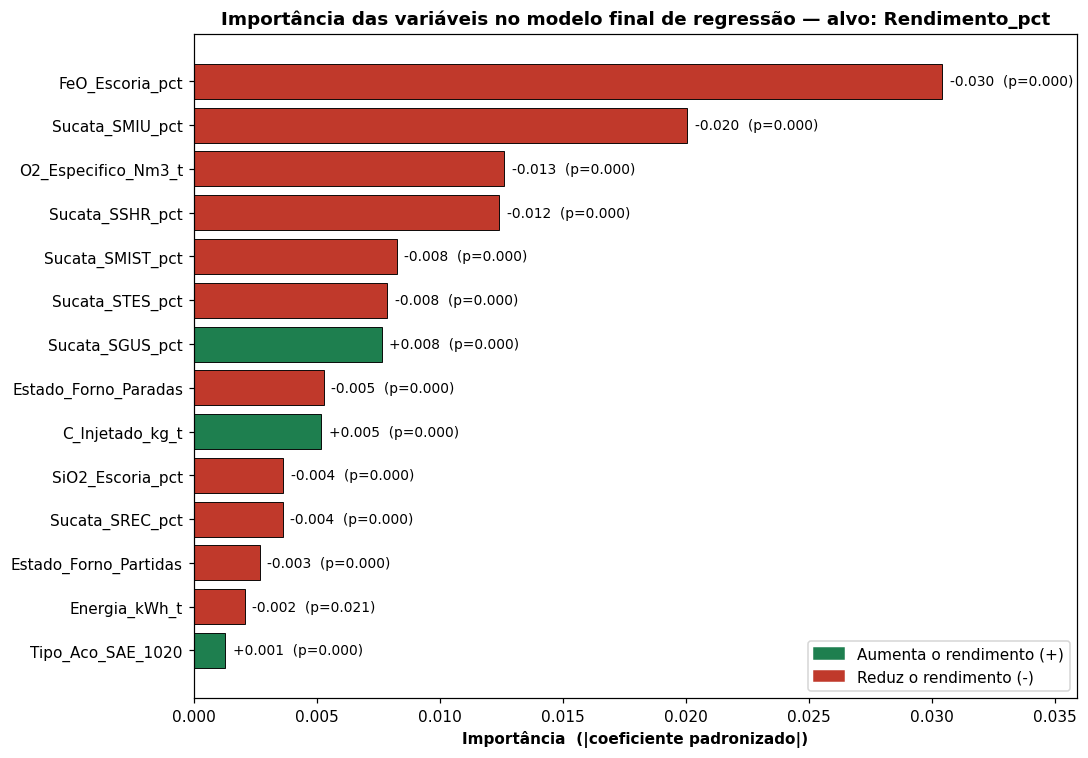

Variáveis do modelo final ordenadas por importância:
                         coef  pvalue
FeO_Escoria_pct       -0.0304  0.0000
Sucata_SMIU_pct       -0.0201  0.0000
O2_Especifico_Nm3_t   -0.0126  0.0000
Sucata_SSHR_pct       -0.0124  0.0000
Sucata_SMIST_pct      -0.0082  0.0000
Sucata_STES_pct       -0.0079  0.0000
Sucata_SGUS_pct        0.0076  0.0000
Estado_Forno_Paradas  -0.0053  0.0000
C_Injetado_kg_t        0.0052  0.0000
SiO2_Escoria_pct      -0.0036  0.0000
Sucata_SREC_pct       -0.0036  0.0002
Estado_Forno_Partidas -0.0027  0.0000
Energia_kWh_t         -0.0021  0.0209
Tipo_Aco_SAE_1020      0.0013  0.0000


In [ ]:
# Célula movida para antes das Conclusões. Pode apagar esta célula.